# Setup env

In [2]:
import os
import cv2
import glob
import random
import PIL
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import montage 
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps  

# neural imaging
import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt

# PyTorch for segmentation
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import gc 
from tqdm import tqdm
import json

np.set_printoptions(precision=3, suppress=True)

# Load data

In [3]:
from sklearn.model_selection import train_test_split
import os

IMG_SIZE = 64

TRAIN_DATASET_PATH = '/home/nvsinh1/brats_segmentation/thesis/data/BraTS2021_Training_Data/'
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]
train_and_val_directories = [
    d for d in train_and_val_directories
]

In [4]:
EVALUATE_DATASET_PATH = '/home/nvsinh1/brats_segmentation/thesis/experiments/data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData'
val_directories = [f.path for f in os.scandir(EVALUATE_DATASET_PATH) if f.is_dir()]
val_directories = sorted(val_directories)
def pathListIntoIds(dirList):
    return [os.path.basename(path) for path in dirList]
evaluate_ids = pathListIntoIds(val_directories)
print(f"📊 First 5 cases: {evaluate_ids[:5]}")

📊 First 5 cases: ['BraTS-GLI-00000-000', 'BraTS-GLI-00002-000', 'BraTS-GLI-00003-000', 'BraTS-GLI-00005-000', 'BraTS-GLI-00006-000']


In [5]:
EVALUATE_DATASET_2_PATH = '/home/nvsinh1/brats_segmentation/thesis/experiments/data/BraTS_Synthesis'
val_2_directories = [f.path for f in os.scandir(EVALUATE_DATASET_2_PATH) if f.is_dir()]
val_2_directories = sorted(val_2_directories)
def pathListIntoIds(dirList):
    return [os.path.basename(path) for path in dirList]
evaluate_2_ids = pathListIntoIds(val_2_directories)
print(f"📊 First 5 cases: {evaluate_2_ids[:5]}")

📊 First 5 cases: ['case_000000', 'case_000001', 'case_000002', 'case_000003', 'case_000004']


In [6]:
# Lấy tên case lỗi từ error log
CORRUPTED_CASE = "cache_patches_npz"  # Case đang gây lỗi

# Danh sách folder
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]

# Lọc bỏ case lỗi
train_and_val_directories = [
    d for d in train_and_val_directories
    if not os.path.basename(d) == CORRUPTED_CASE
]

print(f"✅ Đã loại bỏ case lỗi: {CORRUPTED_CASE}")
print(f"📊 Còn lại: {len(train_and_val_directories)} cases")
def pathListIntoIds(dirList):
    return [os.path.basename(path) for path in dirList]
train_and_test_ids = pathListIntoIds(train_and_val_directories)
train_ids, test_ids = train_test_split(train_and_test_ids, test_size=0.2, random_state=42)

✅ Đã loại bỏ case lỗi: cache_patches_npz
📊 Còn lại: 1251 cases


In [7]:
def split_case_ids(case_ids, train_ratio=0.8, val_ratio=0.1, seed=42):
    cases = sorted(case_ids.copy())
    rng = random.Random(seed)
    rng.shuffle(cases)

    n = len(cases)
    n_train = int(round(n * train_ratio))
    n_val = int(round(n * val_ratio))

    train_cases = cases[:n_train]
    val_cases = cases[n_train:n_train + n_val]
    test_cases = cases[n_train + n_val:]

    return train_cases, val_cases, test_cases
train_ids_1, val_ids_1, test_ids_1 = split_case_ids(
    evaluate_2_ids,
    train_ratio=0.8,
    val_ratio=0.1,
    seed=42,
)
print(f"Train: {len(train_ids_1)}, Val: {len(val_ids_1)}, Test: {len(test_ids_1)}")

Train: 2002, Val: 250, Test: 250


In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe


def visualize_data_split(
    train_ids,
    test_ids,
    val_ids=None,
    year=2021,
    total_original=1251,
    dataset_name="BraTS",
    split_ratio=None,
    random_seed=42,
    stratified=True,
    figsize=(15, 10),
    dpi=300,
    save_path=None
):
    n_train = len(train_ids)
    n_val = len(val_ids) if val_ids is not None else 0
    n_test = len(test_ids)

    n_valid = n_train + n_val + n_test
    n_removed = total_original - n_valid

    if n_valid <= 0:
        raise ValueError("Training, validation, and test sets are empty.")

    train_pct = n_train / n_valid * 100
    val_pct = n_val / n_valid * 100 if n_val > 0 else 0.0
    test_pct = n_test / n_valid * 100

    # Auto split-ratio text
    if split_ratio is None:
        if val_ids is None:
            split_ratio = f"{round(train_pct):.0f}/{round(test_pct):.0f}"
        else:
            split_ratio = f"{round(train_pct):.0f}/{round(val_pct):.0f}/{round(test_pct):.0f}"

    # Format title year nicely
    year_text = "" if year is None else f" {year}"

    # ---------- Theme ----------
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 15,
        "axes.labelsize": 12
    })

    c_bg = "#FAFAFA"
    c_train = "#4C78A8"
    c_val = "#72B7B2"
    c_test = "#E45756"
    c_original = "#DCEAF7"
    c_text = "#1F2937"
    c_muted = "#6B7280"
    c_border = "#D1D5DB"
    c_note = "#FFF7E6"

    fig = plt.figure(figsize=figsize, dpi=dpi, facecolor="white")
    gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1], wspace=0.18)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    for ax in (ax1, ax2):
        ax.set_facecolor(c_bg)

    # ---------- LEFT: Workflow diagram ----------
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.axis("off")

    title = f"{dataset_name}{year_text} Dataset Split Strategy"
    ax1.text(
        5, 9.65, title,
        ha="center", va="top",
        fontsize=17, fontweight="bold", color=c_text
    )
    ax1.text(
        5, 9.15,
        "Quality-controlled cohort preparation and reproducible data partitioning",
        ha="center", va="top",
        fontsize=10.5, color=c_muted
    )

    def rounded_box(ax, x, y, w, h, facecolor, edgecolor, text, text_color=c_text,
                    fontsize=11.5, lw=1.5, rounding=0.08):
        patch = FancyBboxPatch(
            (x, y), w, h,
            boxstyle=f"round,pad=0.02,rounding_size={rounding}",
            linewidth=lw,
            edgecolor=edgecolor,
            facecolor=facecolor
        )
        patch.set_path_effects([
            pe.SimplePatchShadow(offset=(1.5, -1.5), alpha=0.12),
            pe.Normal()
        ])
        ax.add_patch(patch)
        ax.text(
            x + w / 2, y + h / 2, text,
            ha="center", va="center",
            fontsize=fontsize, fontweight="semibold", color=text_color
        )

    # Original dataset
    rounded_box(
        ax1, 1.1, 7.3, 7.8, 1.25,
        facecolor=c_original, edgecolor="#9DBBD9",
        text=f"{dataset_name}{year_text} Original Dataset\n{total_original:,} patients"
    )

    # QC arrow + label
    ax1.annotate(
        "", xy=(5, 6.65), xytext=(5, 7.25),
        arrowprops=dict(arrowstyle="-|>", lw=1.8, color=c_muted)
    )
    ax1.text(
        5.25, 6.93, "Quality control",
        fontsize=10, color=c_muted, style="italic", ha="left"
    )

    # Valid dataset
    valid_text = f"Valid Dataset After QC\n{n_valid:,} patients"
    if n_removed > 0:
        valid_text += f"  |  Removed: {n_removed:,}"
    rounded_box(
        ax1, 1.1, 5.15, 7.8, 1.15,
        facecolor="#E8F5F2", edgecolor="#8CC7BE",
        text=valid_text
    )

    # Split arrow + label
    ax1.annotate(
        "", xy=(5, 4.45), xytext=(5, 5.1),
        arrowprops=dict(arrowstyle="-|>", lw=1.8, color=c_muted)
    )

    if val_ids is None:
        split_label = f"train_test_split ({split_ratio}, seed={random_seed})"
    else:
        split_label = f"train/val/test split ({split_ratio}, seed={random_seed})"

    if stratified:
        split_label += "\nstratified by class"

    ax1.text(
        5.3, 4.7, split_label,
        fontsize=9.8, color=c_muted, style="italic", ha="left", va="center"
    )

    # ---------- Split boxes ----------
    if val_ids is None:
        # Train box
        rounded_box(
            ax1, 0.8, 2.45, 4.0, 1.45,
            facecolor="#EAF1F8", edgecolor=c_train,
            text=f"Training Set\n{n_train:,} patients ({train_pct:.1f}%)",
            text_color=c_train,
            fontsize=11.5,
            lw=1.8
        )

        # Test box
        rounded_box(
            ax1, 5.2, 2.45, 4.0, 1.45,
            facecolor="#FDEDEC", edgecolor=c_test,
            text=f"Test Set\n{n_test:,} patients ({test_pct:.1f}%)",
            text_color=c_test,
            fontsize=11.5,
            lw=1.8
        )

        ax1.text(
            2.8, 1.95,
            "Model development\nand hyperparameter tuning",
            ha="center", va="top",
            fontsize=9.5, color=c_train
        )
        ax1.text(
            7.2, 1.95,
            "Final unbiased\nperformance evaluation",
            ha="center", va="top",
            fontsize=9.5, color=c_test
        )

        principles = (
            "Design principles\n"
            "• Fixed random seed for reproducibility\n"
            "• Stratified split to preserve class distribution\n"
            "• Strict separation between training and test sets\n"
            "• No data leakage during model development"
        )

    else:
        # Train box
        rounded_box(
            ax1, 0.3, 2.45, 3.0, 1.45,
            facecolor="#EAF1F8", edgecolor=c_train,
            text=f"Training Set\n{n_train:,} patients ({train_pct:.1f}%)",
            text_color=c_train,
            fontsize=10.8,
            lw=1.8
        )

        # Val box
        rounded_box(
            ax1, 3.5, 2.45, 3.0, 1.45,
            facecolor="#E8F5F2", edgecolor=c_val,
            text=f"Validation Set\n{n_val:,} patients ({val_pct:.1f}%)",
            text_color=c_val,
            fontsize=10.8,
            lw=1.8
        )

        # Test box
        rounded_box(
            ax1, 6.7, 2.45, 3.0, 1.45,
            facecolor="#FDEDEC", edgecolor=c_test,
            text=f"Test Set\n{n_test:,} patients ({test_pct:.1f}%)",
            text_color=c_test,
            fontsize=10.8,
            lw=1.8
        )

        ax1.text(
            1.8, 1.95,
            "Model training",
            ha="center", va="top",
            fontsize=9.3, color=c_train
        )
        ax1.text(
            5.0, 1.95,
            "Hyperparameter tuning\nand model selection",
            ha="center", va="top",
            fontsize=9.3, color=c_val
        )
        ax1.text(
            8.2, 1.95,
            "Final unbiased\nperformance evaluation",
            ha="center", va="top",
            fontsize=9.3, color=c_test
        )

        principles = (
            "Design principles\n"
            "• Fixed random seed for reproducibility\n"
            "• Stratified split to preserve class distribution\n"
            "• Dedicated validation set for model selection\n"
            "• Strict separation between train, val, and test sets"
        )

    ax1.text(
        5, 0.9, principles,
        ha="center", va="top", fontsize=9.4, color=c_text,
        bbox=dict(
            boxstyle="round,pad=0.45,rounding_size=0.08",
            facecolor=c_note, edgecolor="#E8D8A8", linewidth=1.0
        )
    )

    # ---------- RIGHT: Proportional chart ----------
    ax2.set_title("Post-QC Data Distribution", pad=14, fontweight="bold", color=c_text)

    ax2.barh(["Dataset split"], [n_train], color=c_train, edgecolor="white", height=0.55)

    if val_ids is None:
        ax2.barh(
            ["Dataset split"], [n_test],
            left=[n_train], color=c_test, edgecolor="white", height=0.55
        )
    else:
        ax2.barh(
            ["Dataset split"], [n_val],
            left=[n_train], color=c_val, edgecolor="white", height=0.55
        )
        ax2.barh(
            ["Dataset split"], [n_test],
            left=[n_train + n_val], color=c_test, edgecolor="white", height=0.55
        )

    # Internal labels
    if n_train > 0:
        ax2.text(
            n_train / 2, 0,
            f"Train\n{n_train:,}\n({train_pct:.1f}%)",
            ha="center", va="center",
            color="white", fontsize=7, fontweight="bold"
        )

    if val_ids is not None and n_val > 0:
        ax2.text(
            n_train + n_val / 2, 0,
            f"Val\n{n_val:,}\n({val_pct:.1f}%)",
            ha="center", va="center",
            color="white", fontsize=7, fontweight="bold"
        )

    if n_test > 0:
        x_test = n_train + (n_test / 2 if val_ids is None else n_val + n_test / 2)
        ax2.text(
            x_test, 0,
            f"Test\n{n_test:,}\n({test_pct:.1f}%)",
            ha="center", va="center",
            color="white", fontsize=7, fontweight="bold"
        )

    ax2.set_xlim(0, n_valid * 1.08)
    ax2.set_xlabel("Number of patients", fontweight="bold", color=c_text)
    ax2.tick_params(axis="x", colors=c_muted)
    ax2.tick_params(axis="y", colors=c_text)
    ax2.grid(axis="x", linestyle="--", alpha=0.25)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["bottom"].set_color(c_border)

    summary_text = (
        f"Original cohort: {total_original:,}\n"
        f"Valid after QC: {n_valid:,}\n"
        f"Excluded: {max(n_removed, 0):,}"
    )
    ax2.text(
        0.98, 0.18, summary_text,
        transform=ax2.transAxes,
        ha="right", va="bottom",
        fontsize=10, color=c_text,
        bbox=dict(
            boxstyle="round,pad=0.4,rounding_size=0.08",
            facecolor="white", edgecolor=c_border
        )
    )

    # ---------- Global layout ----------
    if val_ids is None:
        global_title = f"{dataset_name}{year_text}: Cohort Refinement and Train-Test Partition"
    else:
        global_title = f"{dataset_name}{year_text}: Cohort Refinement and Train-Val-Test Partition"

    fig.suptitle(
        global_title,
        y=0.98, fontsize=18, fontweight="bold", color=c_text
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    return fig

/tmp/ipykernel_95661/2283837586.py:348: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


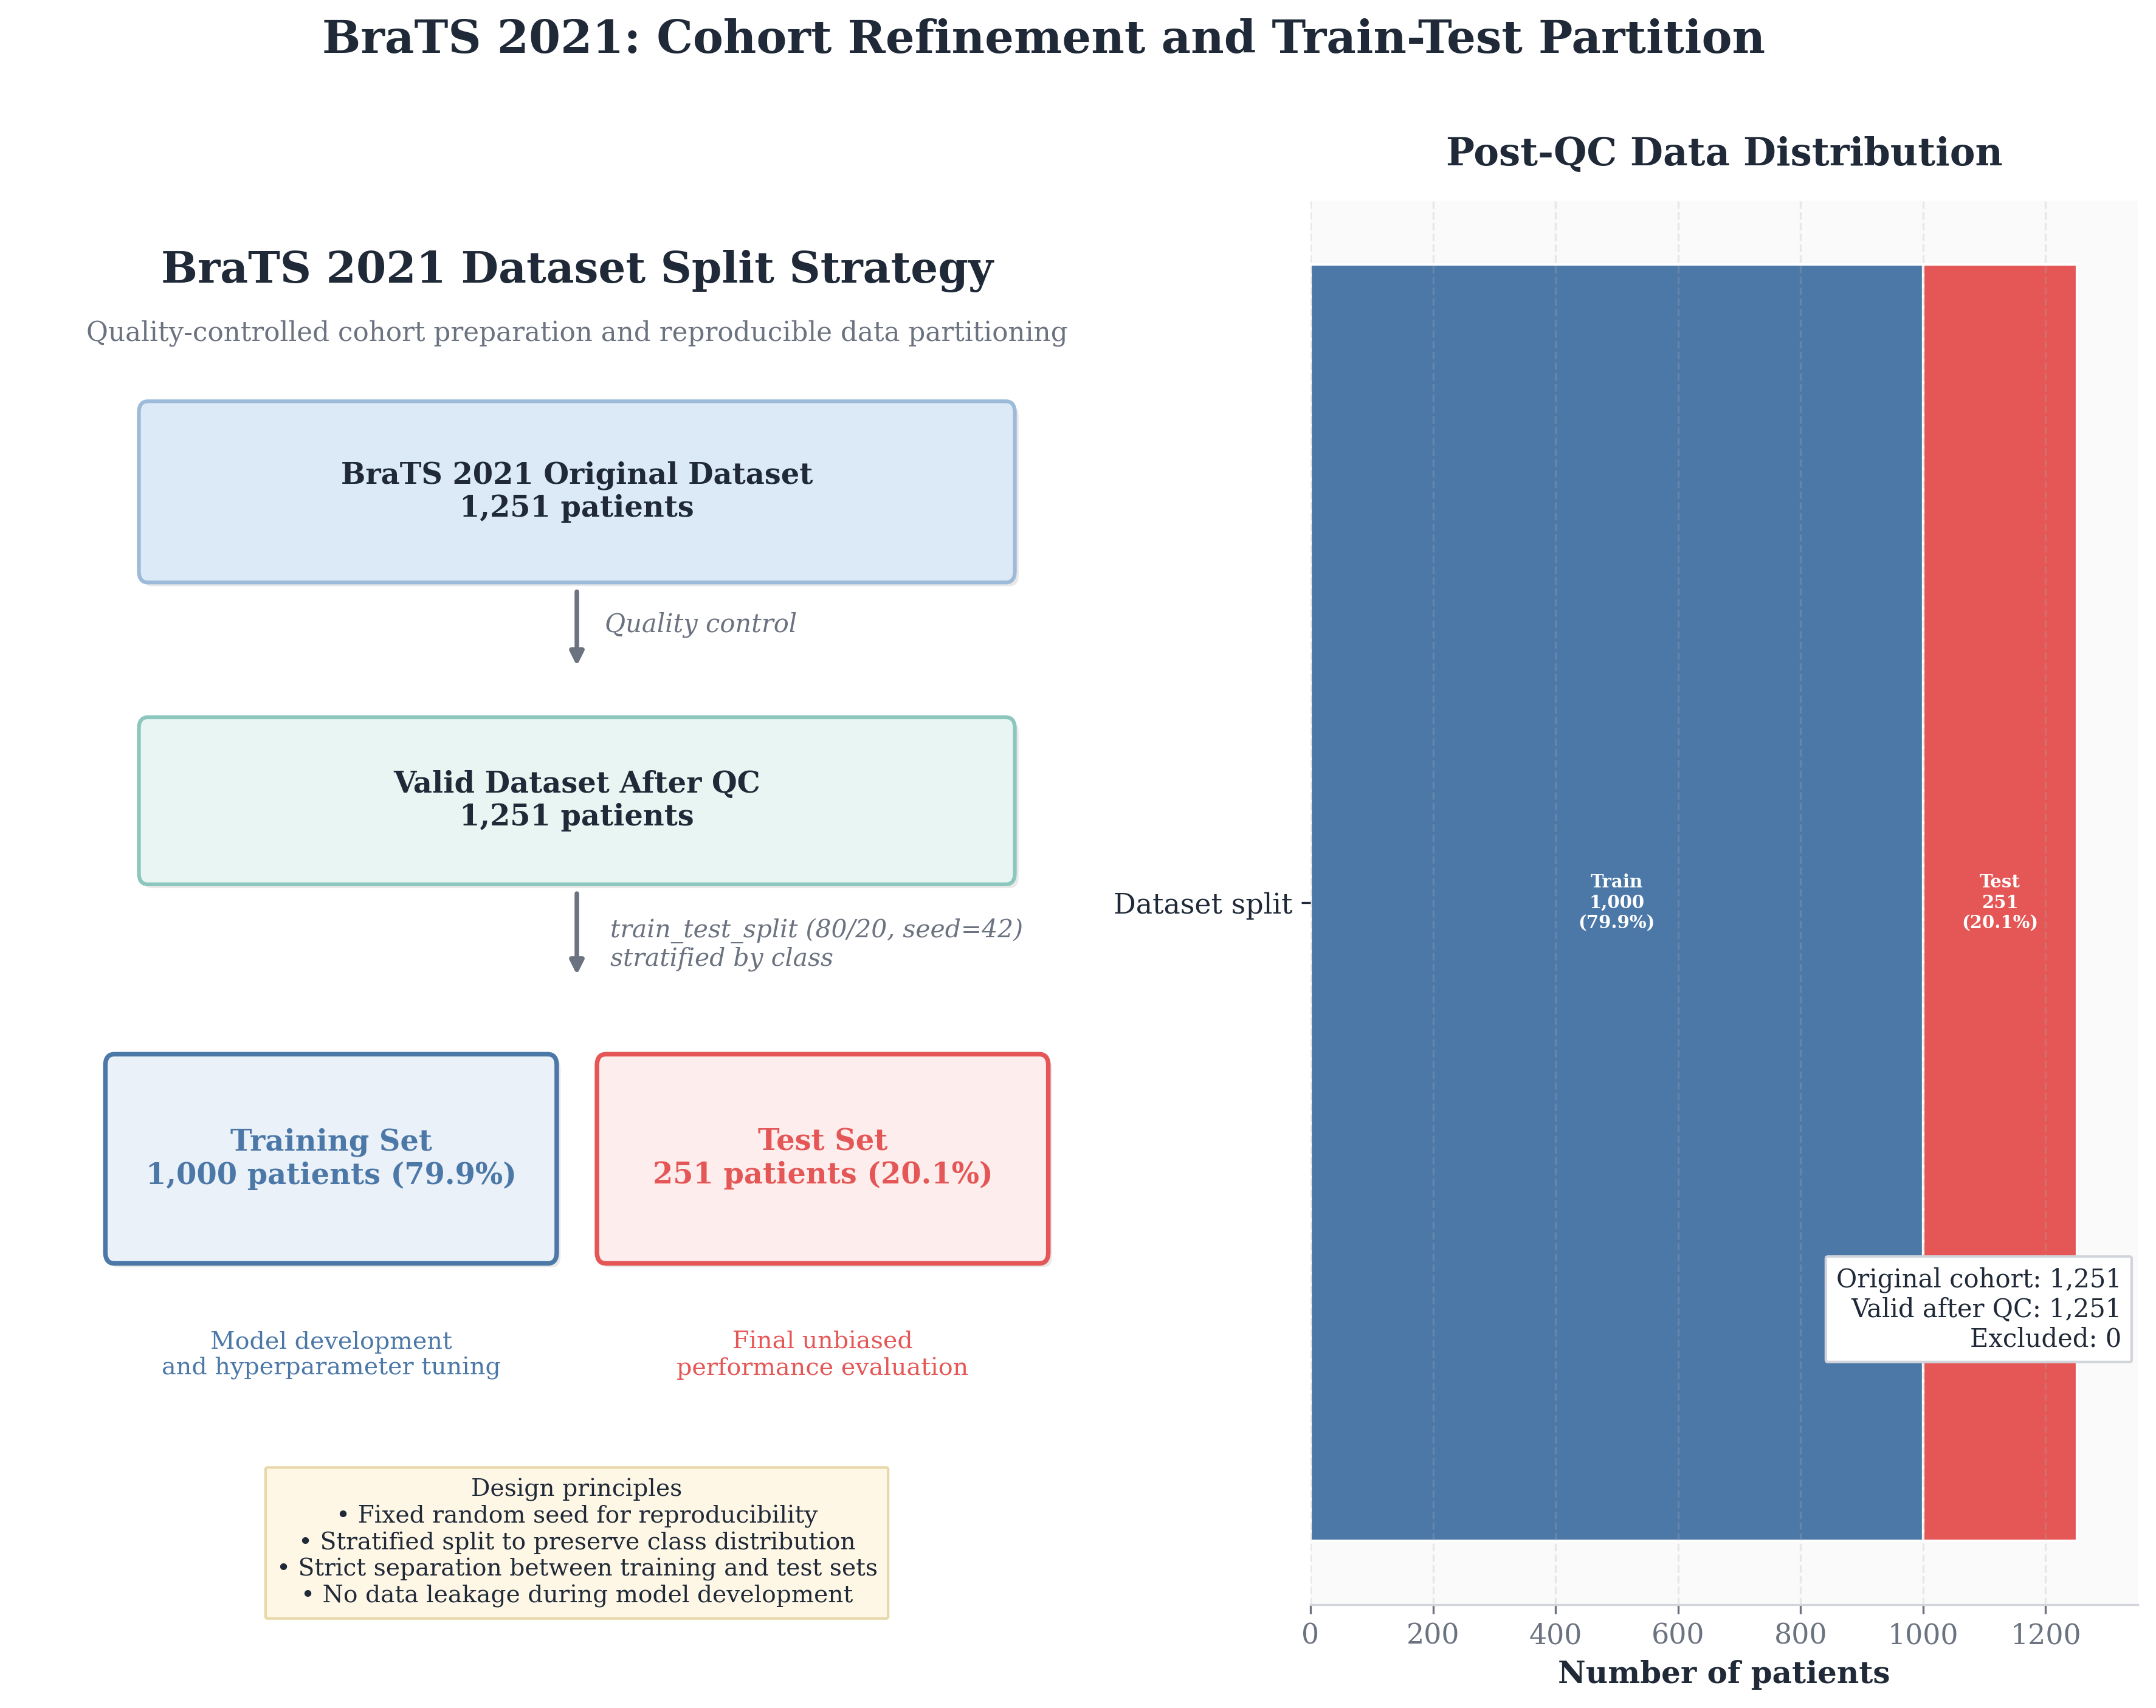

In [9]:
fig = visualize_data_split(
    train_ids=train_ids,
    test_ids=test_ids,
    val_ids=None,
    year=2021,
    total_original=1251,
    dataset_name="BraTS",
    save_path="dataset_split_brats_2021.png"
)
plt.show()

/tmp/ipykernel_95661/2283837586.py:348: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


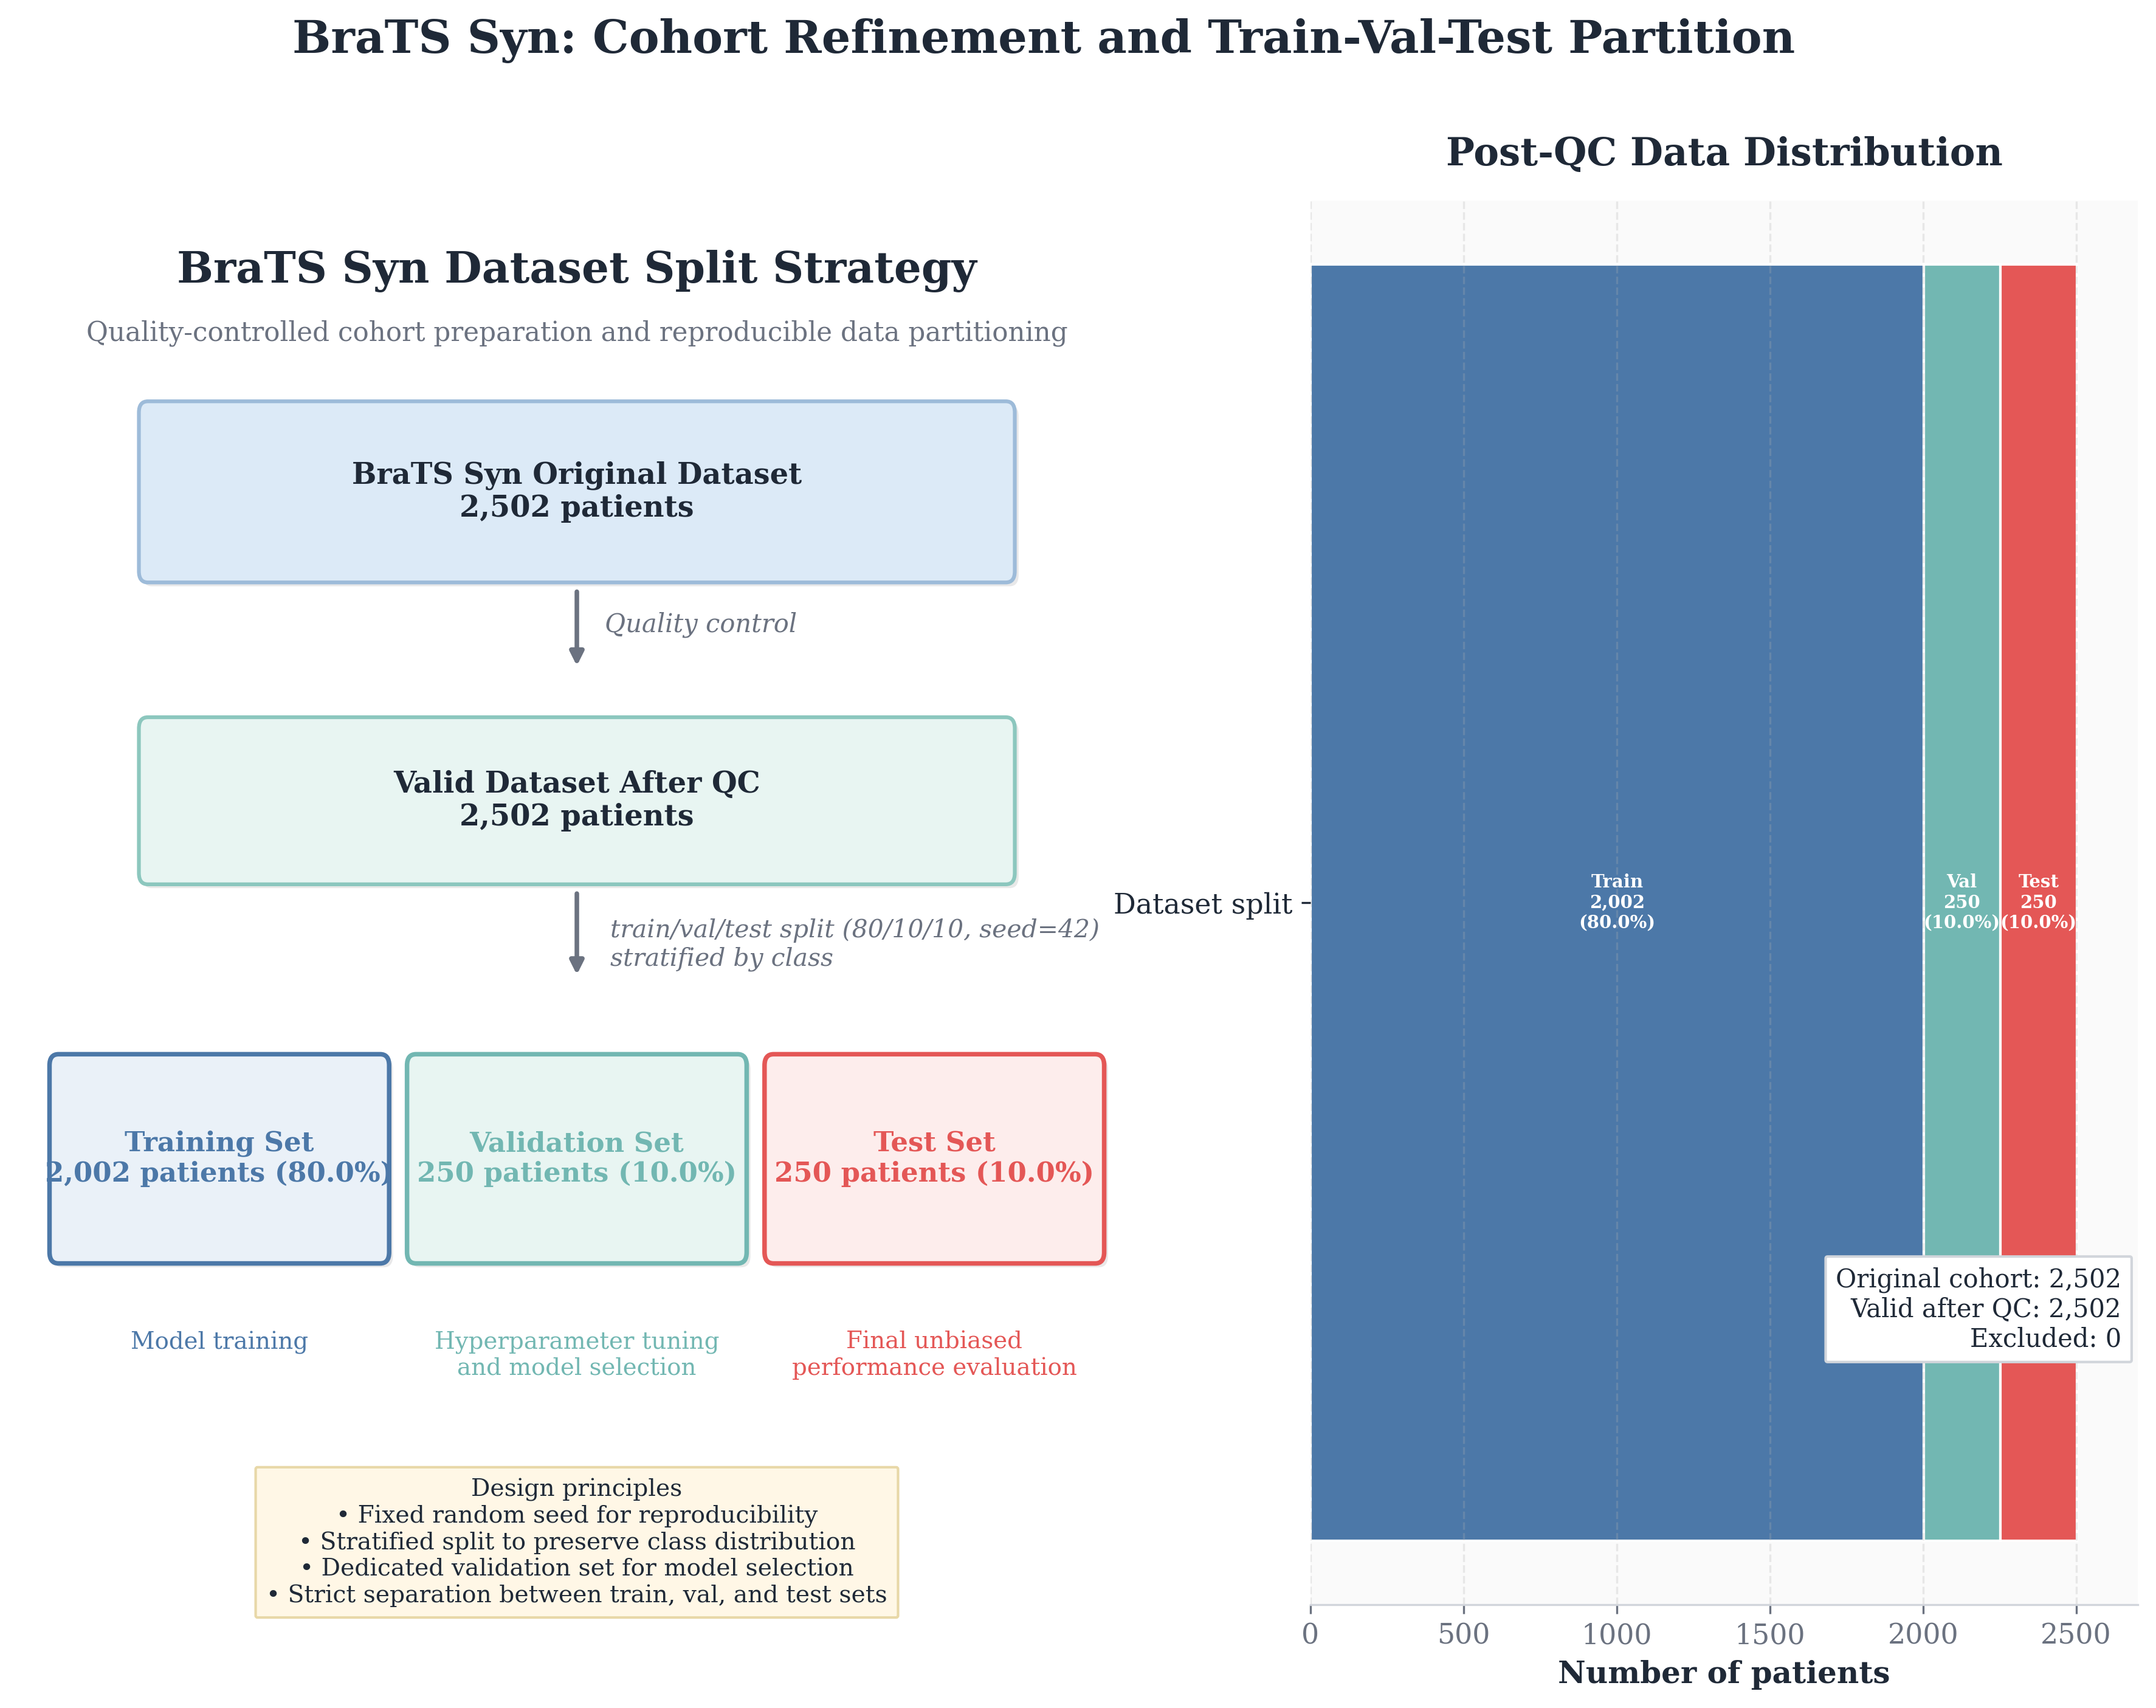

In [10]:
fig = visualize_data_split(
    train_ids=train_ids_1,
    val_ids=val_ids_1,
    test_ids=test_ids_1,
    year="Syn",
    total_original=len(evaluate_2_ids),
    dataset_name="BraTS",
    save_path="dataset_split_brats_syn.png"
)
plt.show()

#

# Data Augmentation

In [23]:
import tempfile
import hashlib
import time
from torch.utils.data import Dataset
import numpy as np
import random
import torch
import os
import nibabel as nib
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    Compose,
    RandFlipd,
    RandAffined,
    RandGaussianNoised,
    ResizeWithPadOrCropd,
)

In [12]:
%pip install monai


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
from monai.transforms import (
    Compose, RandFlipd, RandAffined, RandGaussianNoised
)

def augment(volume, mask):
    # BEFORE: volume (H,W,D,C), mask (H,W,D)
    # Convert to MONAI expected format
    volume = np.transpose(volume, (3, 0, 1, 2))  # (C, H, W, D)
    mask = np.expand_dims(mask, axis=0)         # (1, H, W, D)

    data = {"image": volume, "label": mask}

    train_aug = Compose([
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[0, 1, 2]),
        RandAffined(
            keys=["image", "label"],
            prob=0.3,
            rotate_range=(0.1, 0.1, 0.1),
            scale_range=(0.1, 0.1, 0.1),
            mode=("bilinear", "nearest")   # image = bilinear, mask = nearest
        ),
        RandGaussianNoised(keys=["image"], prob=0.2, std=0.01),
    ])

    data = train_aug(data)

    # Convert back to (H,W,D,C) and (H,W,D)
    volume = np.transpose(data["image"], (1, 2, 3, 0))  # (H,W,D,C)
    mask = data["label"][0]                             # (H,W,D)

    return volume, mask

<frozen importlib._bootstrap_external>:1297: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [14]:
def adaptive_threshold_per_modality(vol, lower_percentile=0.5, upper_percentile=99.9):
    for c in range(vol.shape[-1]):
        img = vol[..., c]
        if img.max() > 0:
            nonzero = img[img > 0]
            if len(nonzero) > 10:  # Đảm bảo có đủ samples
                lower = np.percentile(nonzero, lower_percentile)
                upper = np.percentile(nonzero, upper_percentile)
                img = np.clip(img, lower, upper)
                vol[..., c] = img
    return vol

def fixed_threshold_per_modality(vol, threshold_dict=None):
    if threshold_dict is None:
        # ✅ Giảm threshold xuống để không mất thông tin
        threshold_dict = {
            0: 0.5,   # FLAIR - giảm từ 2
            1: 0.2,   # T1 - giảm từ 1
            2: 0.8,   # T1CE - giảm từ 3
            3: 0.5    # T2 - giảm từ 2
        }
    for c in range(vol.shape[-1]):
        thresh = threshold_dict.get(c, 0)
        vol[..., c][vol[..., c] < thresh] = 0
    return vol

In [16]:
class PatchDataGenerator(Dataset):
    def __init__(self, list_IDs, dataset_root, patch_size=(64,64,64), patches_per_volume=20, n_channels=4, n_classes=4, shuffle=True, augmentation=None, use_threshold=True, threshold_method='adaptive', tumor_sampling_strategy='balanced', min_tumor_ratio=0.01):
        self.list_IDs = list_IDs
        self.dataset_root = dataset_root
        self.patch_size = np.array(patch_size)
        self.patches_per_volume = patches_per_volume
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.augmentation = augmentation
        self.use_threshold = use_threshold
        self.threshold_method = threshold_method
        self.tumor_sampling_strategy = tumor_sampling_strategy
        self.min_tumor_ratio = min_tumor_ratio
        
        self.patch_indices = [(case, i) for case in self.list_IDs for i in range(self.patches_per_volume)]
        if self.shuffle:
            random.shuffle(self.patch_indices)

    def __len__(self):
        return len(self.patch_indices)

    def __getitem__(self, index):
        case_id, _ = self.patch_indices[index]
        vol, seg = self._load_volume(case_id)
        if vol is None:
            # skip corrupted case → return next valid sample
            return self.__getitem__((index + 1) % len(self.patch_indices))
        if self.use_threshold:
            vol = self._thresholding_per_modality(vol)
        vol = self._normalize_per_modality(vol)
        
        target = self._decide_patch_target()
        for attempt in range(12):
            if target == 'tumor_focus':
                vol_patch, seg_patch = self._get_tumor_center_crop(vol, seg)
            else:
                vol_patch, seg_patch = self._random_crop_3d(vol, seg)
            
            tumor_ratio = np.mean(seg_patch > 0)
            if target != 'tumor_focus' or tumor_ratio >= self.min_tumor_ratio:
                break
        
        if self.augmentation is not None:
            vol_patch, seg_patch = self.augmentation(vol_patch, seg_patch)
            if isinstance(vol_patch, torch.Tensor): 
                vol_patch = vol_patch.cpu().numpy()
            if isinstance(seg_patch, torch.Tensor): 
                seg_patch = seg_patch.cpu().numpy()
        
        X = torch.from_numpy(vol_patch).permute(3,0,1,2).float()
        y = torch.from_numpy(seg_patch).long()
        
        return X, y

    def _load_volume(self, case_id):
        try:
            case_dir = os.path.join(self.dataset_root, case_id)
            vols = []
            for mod in ['flair','t1','t1ce','t2']:
                path = os.path.join(case_dir, f"{case_id}_{mod}.nii.gz")
                if not os.path.exists(path):
                    print(f"[WARN] Missing file: {path} → skipping")
                    return None, None

                img = nib.load(path).get_fdata(dtype=np.float32)
                vols.append(img)

            seg_path = os.path.join(case_dir, f"{case_id}_seg.nii.gz")
            if not os.path.exists(seg_path):
                print(f"[WARN] Missing segmentation: {seg_path} → skipping")
                return None, None

            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            seg[seg == 4] = 3

            vol = np.stack(vols, axis=-1)
            return vol, seg

        except Exception as e:
            print(f"[ERROR] Failed loading case {case_id}: {e}")
            return None, None


    def _thresholding_per_modality(self, vol):
        if self.threshold_method == 'adaptive':
            return adaptive_threshold_per_modality(vol, lower_percentile=0.5, upper_percentile=99.9)
        return fixed_threshold_per_modality(vol)

    def _normalize_per_modality(self, vol):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                m, s = img[mask].mean(), img[mask].std()
                if s > 1e-7:
                    vol[..., c][mask] = (img[mask] - m) / s
                else:
                    vol[..., c][mask] = img[mask] - m
        return vol

    def _get_tumor_center_crop(self, vol, seg):
        tumor_mask = seg > 0
        if not tumor_mask.any():
            return self._random_crop_3d(vol, seg)
        coords = np.where(tumor_mask)
        center = np.array([(c.min()+c.max())//2 for c in coords])
        size = self.patch_size
        start = np.clip(center - size//2, 0, np.array(vol.shape[:3]) - size)
        jitter = np.random.randint(-size//6, size//6+1, size=3)
        start = np.clip(start + jitter, 0, np.array(vol.shape[:3]) - size)
        end = start + size
        return vol[start[0]:end[0], start[1]:end[1], start[2]:end[2], :], seg[start[0]:end[0], start[1]:end[1], start[2]:end[2]]

    def _random_crop_3d(self, vol, seg):
        H, W, D = vol.shape[:3]
        ph, pw, pd = self.patch_size
        h = random.randint(0, H-ph)
        w = random.randint(0, W-pw)
        d = random.randint(0, D-pd)
        return vol[h:h+ph, w:w+pw, d:d+pd, :], seg[h:h+ph, w:w+pw, d:d+pd]

    def _decide_patch_target(self):
        if self.tumor_sampling_strategy == 'random':
            return 'any'
        if self.tumor_sampling_strategy == 'tumor_focus':
            return 'tumor_focus' if random.random() < 0.8 else 'any'
        if self.tumor_sampling_strategy == 'balanced':
            r = random.random()
            return 'tumor_focus' if r < 0.4 else 'any'
        return 'any'

In [17]:
class VolumeDataGenerator(torch.utils.data.Dataset):
    def __init__(self, list_IDs, dataset_root, n_channels=4, n_classes=4, use_threshold=True, threshold_method='adaptive'):
        self.list_IDs = list_IDs
        self.dataset_root = dataset_root
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.use_threshold = use_threshold
        self.threshold_method = threshold_method

    def __len__(self):
        return len(self.list_IDs)

    def __getitem__(self, idx):
        case_id = self.list_IDs[idx]

        vol, seg = self._load_volume(case_id)
        if vol is None:
            # skip corrupted → try next
            return self.__getitem__((idx + 1) % len(self.list_IDs))

        # SAME preprocessing as train
        if self.use_threshold:
            vol = self._thresholding_per_modality(vol)

        vol = self._normalize_per_modality(vol)

        # (H,W,D,C) → (C,H,W,D)
        X = torch.from_numpy(vol).permute(3, 0, 1, 2).float()
        y = torch.from_numpy(seg).long()

        return X, y, case_id
    
    def _load_volume(self, case_id):
        try:
            case_dir = os.path.join(self.dataset_root, case_id)
            vols = []
            for mod in ['flair','t1','t1ce','t2']:
                path = os.path.join(case_dir, f"{case_id}_{mod}.nii.gz")
                if not os.path.exists(path):
                    print(f"[WARN] Missing file: {path}")
                    return None, None

                img = nib.load(path).get_fdata(dtype=np.float32)
                vols.append(img)

            seg_path = os.path.join(case_dir, f"{case_id}_seg.nii.gz")
            if not os.path.exists(seg_path):
                print(f"[WARN] Missing segmentation: {seg_path}")
                return None, None

            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            seg[seg == 4] = 3

            vol = np.stack(vols, axis=-1)  # (H,W,D,C)
            return vol, seg

        except Exception as e:
            print(f"[ERROR] Failed loading case {case_id}: {e}")
            return None, None


    def _thresholding_per_modality(self, vol):
        if self.threshold_method == 'adaptive':
            return adaptive_threshold_per_modality(
                vol, lower_percentile=0.5, upper_percentile=99.9
            )
        return fixed_threshold_per_modality(vol)


    def _normalize_per_modality(self, vol):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                m, s = img[mask].mean(), img[mask].std()
                if s > 1e-7:
                    vol[..., c][mask] = (img[mask] - m) / s
                else:
                    vol[..., c][mask] = img[mask] - m
        return vol

In [18]:
class VolumeDataGeneratorEval(torch.utils.data.Dataset):
    def __init__(self, list_IDs, dataset_root, n_channels=4, n_classes=4, use_threshold=True, threshold_method='adaptive'):
        self.list_IDs = list_IDs
        self.dataset_root = dataset_root
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.use_threshold = use_threshold
        self.threshold_method = threshold_method

    def __len__(self):
        return len(self.list_IDs)

    def __getitem__(self, idx):
        case_id = self.list_IDs[idx]

        vol, seg = self._load_volume(case_id)
        if vol is None:
            return self.__getitem__((idx + 1) % len(self.list_IDs))
        
        if self.use_threshold:
            vol = self._thresholding_per_modality(vol)

        vol = self._normalize_per_modality(vol)

        # (H,W,D,C) → (C,H,W,D)
        X = torch.from_numpy(vol).permute(3, 0, 1, 2).float()
        y = torch.from_numpy(seg).long()

        return X, y, case_id
    
    def _load_volume(self, case_id):
        try:
            case_dir = os.path.join(self.dataset_root, case_id)
            modality_map = {
                't2f': 't2f',
                't1n': 't1n',
                't1c': 't1c',
                't2w': 't2w'
            }
            vols = []
            for mod in modality_map.values():
                path = os.path.join(
                    case_dir,
                    f"{case_id}-{mod}.nii.gz"
                )
                if not os.path.exists(path):
                    print(f"[WARN] Missing file: {path}")
                    return None, None

                img = nib.load(path).get_fdata(dtype=np.float32)
                vols.append(img)

            seg_path = os.path.join(
                case_dir,
                f"{case_id}-seg.nii.gz"
            )
            if not os.path.exists(seg_path):
                print(f"[WARN] Missing segmentation: {seg_path}")
                return None, None
            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            seg[seg == 4] = 3  
            vol = np.stack(vols, axis=-1)  # (H, W, D, C)
            return vol, seg
        except Exception as e:
            print(f"[ERROR] Failed loading case {case_id}: {e}")
            return None, None

    def _thresholding_per_modality(self, vol):
        if self.threshold_method == 'adaptive':
            return adaptive_threshold_per_modality(
                vol, lower_percentile=0.5, upper_percentile=99.9
            )
        return fixed_threshold_per_modality(vol)


    def _normalize_per_modality(self, vol):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                m, s = img[mask].mean(), img[mask].std()
                if s > 1e-7:
                    vol[..., c][mask] = (img[mask] - m) / s
                else:
                    vol[..., c][mask] = img[mask] - m
        return vol

In [19]:
training_generator = PatchDataGenerator(
    list_IDs=train_ids,
    dataset_root=TRAIN_DATASET_PATH,
    patch_size=(64, 64, 64),
    patches_per_volume=6,
    n_channels=4,
    n_classes=4,
    shuffle=False,
    augmentation=augment,
    use_threshold=True,
    tumor_sampling_strategy='tumor_focus',
    min_tumor_ratio=0.01
)
training_loader = DataLoader(
    training_generator,
    batch_size=6,
    shuffle=False,           # patch_indices đã shuffle
    num_workers=6,           # parallel loading
    pin_memory=True,
    drop_last=True,
    persistent_workers=True
)

In [20]:
test_dataset = VolumeDataGenerator(
    list_IDs=test_ids,
    dataset_root=TRAIN_DATASET_PATH,
    use_threshold=True,
    threshold_method='adaptive'
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,   
    shuffle=False,
    num_workers=1,
    pin_memory=True
)

In [21]:
evaluate_dataset = VolumeDataGeneratorEval(
    list_IDs=evaluate_ids,
    dataset_root=EVALUATE_DATASET_PATH,
    use_threshold=True,
    threshold_method='adaptive'
)
evaluate_loader = DataLoader(
    evaluate_dataset,
    batch_size=1,   
    shuffle=False,
    num_workers=1,
    pin_memory=True
) 

In [24]:
MODALITIES = ["t1", "t1ce", "t2", "flair"]

class BraTSDataset(Dataset):
    def __init__(
        self,
        dataset_root,
        cases,
        augmentation=False,
        spatial_size=(128, 128, 144),
        include_seg=False,
        normalization="percentile",
        percentile_range=(0.5, 99.5),
        normalize=True,
    ):
        self.dataset_root = dataset_root
        self.cases = cases
        self.augmentation = augmentation
        self.spatial_size = spatial_size
        self.include_seg = include_seg
        self.normalization = normalization
        self.percentile_range = percentile_range
        self.normalize = normalize

        resize_keys = ["image"] + (["label"] if include_seg else [])
        self.resize = ResizeWithPadOrCropd(
            keys=resize_keys,
            spatial_size=self.spatial_size,
        )

        if augmentation:
            aug_keys = ["image"] + (["label"] if include_seg else [])
            self.aug = Compose([
                RandFlipd(keys=aug_keys, prob=0.5, spatial_axis=[0, 1, 2]),
                RandAffined(
                    keys=aug_keys,
                    prob=0.3,
                    rotate_range=(0.1, 0.1, 0.1),
                    scale_range=(0.1, 0.1, 0.1),
                    mode=("bilinear", "nearest") if include_seg else "bilinear",
                ),
                RandGaussianNoised(keys=["image"], prob=0.2, std=0.01),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self.cases)

    def _load_volume(self, case_id):
        case_dir = os.path.join(self.dataset_root, case_id)
        vols = []

        for mod in MODALITIES:
            path = os.path.join(case_dir, f"{mod}.nii.gz")
            if not os.path.exists(path):
                print(f"[WARN] Missing {mod} in {case_id}")
                return None, None
            try:
                img = nib.load(path).get_fdata(dtype=np.float32)
            except Exception as e:
                print(f"[ERROR] Cannot load {path}: {e}")
                return None, None
            vols.append(img)

        vol = np.stack(vols, axis=-1)  # (H, W, D, C)

        seg = None
        if self.include_seg:
            seg_path = os.path.join(case_dir, "seg.nii.gz")
            if os.path.exists(seg_path):
                seg = nib.load(seg_path).get_fdata().astype(np.uint8)
                seg[seg == 4] = 3
            else:
                print(f"[WARN] Missing seg in {case_id}")
                return None, None

        return vol, seg

    def _normalize_img(self, img):
        img = img.astype(np.float32)
        mask = img > 0

        if not np.any(mask):
            return np.zeros_like(img, dtype=np.float32)

        vals = img[mask]

        if self.normalization == "zscore":
            mean = float(vals.mean())
            std = float(vals.std())
            std = std if std > 1e-6 else 1.0
            img_norm = np.zeros_like(img, dtype=np.float32)
            img_norm[mask] = (img[mask] - mean) / std
            img_norm = np.clip(img_norm, -5.0, 5.0)
            lo, hi = -5.0, 5.0
            img_norm = (img_norm - lo) / (hi - lo)
        else:
            lo = float(np.percentile(vals, self.percentile_range[0]))
            hi = float(np.percentile(vals, self.percentile_range[1]))
            img_norm = np.clip(img, lo, hi)
            if hi > lo:
                img_norm = (img_norm - lo) / (hi - lo)
            else:
                img_norm = np.zeros_like(img_norm, dtype=np.float32)

        img_norm = img_norm * 2.0 - 1.0
        return img_norm.astype(np.float32)

    def _process_volume(self, vol):
        out = np.zeros_like(vol, dtype=np.float32)
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            if self.normalize:
                out[..., c] = self._normalize_img(img)
            else:
                out[..., c] = img.astype(np.float32)
        return out

    def __getitem__(self, index):
        case_id = self.cases[index]
        vol, seg = self._load_volume(case_id)

        if vol is None:
            return self.__getitem__((index + 1) % len(self))

        vol = self._process_volume(vol)

        image = np.transpose(vol, (3, 0, 1, 2)).astype(np.float32)  # (4, H, W, D)

        data = {"image": image}

        if self.include_seg and seg is not None:
            label = seg[np.newaxis, ...].astype(np.uint8)
            data["label"] = label

        data = self.resize(data)

        if self.aug is not None:
            data = self.aug(data)

        image = data["image"]
        if isinstance(image, np.ndarray):
            image = torch.from_numpy(image)
        image = image.float()

        output = {
            "image": image,
            "domain_id": torch.tensor(0, dtype=torch.long),
            "case_id": case_id,
        }

        if self.include_seg and "label" in data:
            label = data["label"]
            if isinstance(label, np.ndarray):
                label = torch.from_numpy(label)

            if label.ndim == 4 and label.shape[0] == 1:
                label = label.squeeze(0)

            output["label"] = label.long()

        return output

def split_cases(dataset_root, train_ratio=0.8, val_ratio=0.1, seed=42):
    case_dirs = [f.path for f in os.scandir(dataset_root) if f.is_dir()]
    case_ids = sorted([os.path.basename(p) for p in case_dirs])

    rng = random.Random(seed)
    rng.shuffle(case_ids)

    n = len(case_ids)
    n_train = int(round(n * train_ratio))
    n_val = int(round(n * val_ratio))

    train_cases = case_ids[:n_train]
    val_cases = case_ids[n_train:n_train + n_val]
    test_cases = case_ids[n_train + n_val:]

    return train_cases, val_cases, test_cases

In [ ]:
dataset_root = "/home/nvsinh1/brats_segmentation/thesis/experiments/data/BraTS_Synthesis"

train_cases, val_cases, test_cases = split_cases(
    dataset_root=dataset_root,
    train_ratio=0.8,
    val_ratio=0.1,
    seed=42,
)

train_syn_dataset = BraTSDataset(
    dataset_root=dataset_root,
    cases=train_cases,
    augmentation=False,
    spatial_size=(128, 128, 144),
    include_seg=True,
    normalization="percentile",
    percentile_range=(0.5, 99.5),
    normalize=True,
)

val_syn_dataset = BraTSDataset(
    dataset_root=dataset_root,
    cases=val_cases,
    augmentation=False,
    spatial_size=(128, 128, 144),
    include_seg=True,
    normalization="percentile",
    percentile_range=(0.5, 99.5),
    normalize=True,
)

test_syn_dataset = BraTSDataset(
    dataset_root=dataset_root,
    cases=test_cases,
    augmentation=False,
    spatial_size=(128, 128, 144),
    include_seg=True,
    normalization="percentile",
    percentile_range=(0.5, 99.5),
    normalize=True,
)

train_syn_loader = DataLoader(
    train_syn_dataset,
    batch_size=2,                        
    shuffle=False,
    num_workers=2,                       
    pin_memory=True,
    drop_last=False,
    persistent_workers=True,
    prefetch_factor=1,
)

val_syn_loader = DataLoader(
    val_syn_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True,
    prefetch_factor=1,
)

test_syn_loader = DataLoader(
    test_syn_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True,
    prefetch_factor=1,
)

Train cases: 2002


In [27]:
def get_case_ids(dataset_root, exclude_case_ids=None, sort_ids=True):
    """
    Get case folder names from dataset root.
    Works for formats such as:
    - BraTS2021_xxx
    - BraTS-GLI-xxxxx
    - case_000000
    """
    exclude_case_ids = set(exclude_case_ids or [])

    case_ids = []
    for f in os.scandir(dataset_root):
        if f.is_dir():
            case_id = os.path.basename(f.path)
            if case_id not in exclude_case_ids:
                case_ids.append(case_id)

    if sort_ids:
        case_ids = sorted(case_ids)

    return case_ids


def resolve_case_filepaths(case_id, dataset_root, modality="t1ce"):
    """
    Resolve modality and segmentation file paths across multiple BraTS-style formats.

    Supported examples
    ------------------
    1) 2021 style:
       case_id/case_id_t1ce.nii.gz
       case_id/case_id_seg.nii.gz

    2) 2023/2024 BraTS-GLI style:
       case_id/case_id-t1c.nii
       case_id/case_id-seg.nii

    3) Synthesys / simplified folder style:
       case_000000/t1ce.nii.gz
       case_000000/seg.nii.gz
    """
    case_dir = os.path.join(dataset_root, case_id)
    if not os.path.isdir(case_dir):
        raise FileNotFoundError(
            f"Case directory not found: {case_dir}\n"
            f"Check whether case_id matches an actual folder name in dataset_root."
        )

    modality = modality.lower()

    modality_aliases = {
        "t1c": ["t1c", "t1ce"],
        "t1ce": ["t1ce", "t1c"],
        "t1": ["t1"],
        "t2": ["t2"],
        "flair": ["flair"],
    }
    modality_candidates = modality_aliases.get(modality, [modality])

    modality_patterns = []
    seg_patterns = []

    for m in modality_candidates:
        modality_patterns.extend([
            # 2021 style
            os.path.join(case_dir, f"{case_id}_{m}.nii.gz"),
            os.path.join(case_dir, f"{case_id}_{m}.nii"),

            # 2023/2024 BraTS-GLI style
            os.path.join(case_dir, f"{case_id}-{m}.nii.gz"),
            os.path.join(case_dir, f"{case_id}-{m}.nii"),

            # Synthesys style
            os.path.join(case_dir, f"{m}.nii.gz"),
            os.path.join(case_dir, f"{m}.nii"),
        ])

    seg_patterns.extend([
        # 2021 style
        os.path.join(case_dir, f"{case_id}_seg.nii.gz"),
        os.path.join(case_dir, f"{case_id}_seg.nii"),

        # 2023/2024 BraTS-GLI style
        os.path.join(case_dir, f"{case_id}-seg.nii.gz"),
        os.path.join(case_dir, f"{case_id}-seg.nii"),

        # Synthesys style
        os.path.join(case_dir, "seg.nii.gz"),
        os.path.join(case_dir, "seg.nii"),
    ])

    modality_path = next((p for p in modality_patterns if os.path.exists(p)), None)
    seg_path = next((p for p in seg_patterns if os.path.exists(p)), None)

    if modality_path is None:
        available_files = sorted(os.listdir(case_dir))
        raise FileNotFoundError(
            f"Modality file not found for case '{case_id}' with modality '{modality}'.\n"
            f"Searched patterns:\n" + "\n".join(modality_patterns) +
            f"\nAvailable files in case folder:\n" + "\n".join(available_files)
        )

    if seg_path is None:
        available_files = sorted(os.listdir(case_dir))
        raise FileNotFoundError(
            f"Segmentation file not found for case '{case_id}'.\n"
            f"Searched patterns:\n" + "\n".join(seg_patterns) +
            f"\nAvailable files in case folder:\n" + "\n".join(available_files)
        )

    return modality_path, seg_path

In [28]:
def zscore_normalize_nonzero(volume, eps=1e-8):
    volume = volume.astype(np.float32)

    mask = volume > 0
    if not np.any(mask):
        return volume

    mean = volume[mask].mean()
    std = volume[mask].std()

    volume_norm = volume.copy()
    volume_norm[mask] = (volume[mask] - mean) / (std + eps)

    return volume_norm

def choose_representative_slice(seg, fallback_volume=None):
    # count tumor pixels per slice
    tumor_counts = seg.sum(axis=(0, 1))

    if tumor_counts.max() > 0:
        # slice with largest tumor region
        return int(np.argmax(tumor_counts))

    # fallback if segmentation empty
    if fallback_volume is not None:
        intensity_per_slice = fallback_volume.mean(axis=(0, 1))
        return int(np.argmax(intensity_per_slice))

    # default center slice
    return seg.shape[2] // 2

def visualize_preprocessing_stages(
    case_id,
    dataset_root,
    year=None,
    modality="t1ce",
    percentile_low=0.5,
    percentile_high=99.9,
    slice_idx=None,
    figsize=(16, 9),
    dpi=300,
    save_path=None
):
    modality_path, seg_path = resolve_case_filepaths(case_id, dataset_root, modality=modality)
    vol_original = nib.load(modality_path).get_fdata(dtype=np.float32)
    seg = nib.load(seg_path).get_fdata().astype(np.uint8)

    vol_stage1 = vol_original.copy()

    vol_stage2 = np.expand_dims(vol_stage1.copy(), axis=-1)
    vol_stage2 = adaptive_threshold_per_modality(vol_stage2, percentile_low, percentile_high)
    vol_stage2 = vol_stage2[..., 0]

    vol_stage3 = zscore_normalize_nonzero(vol_stage2)

    if slice_idx is None:
        slice_idx = choose_representative_slice(seg, fallback_volume=vol_stage1)

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11
    })

    c_text = "#1F2937"
    c_muted = "#6B7280"
    c_grid = "#D1D5DB"
    c_hist = "#4C78A8"
    c_box = "#FFF7E6"

    fig, axes = plt.subplots(
        2, 3,
        figsize=figsize,
        dpi=dpi,
        gridspec_kw={"height_ratios": [1.15, 0.85]}
    )
    fig.patch.set_facecolor("white")

    stages = [
        (vol_stage1, "Original"),
        (vol_stage2, "After Thresholding"),
        (vol_stage3, "After Normalization")
    ]

    for i, (vol, stage_title) in enumerate(stages):
        slice_data = vol[:, :, slice_idx]

        ax_img = axes[0, i]

        nonzero = slice_data[slice_data > 0]
        if nonzero.size > 0:
            vmin = np.percentile(nonzero, 1)
            vmax = np.percentile(nonzero, 99)
            if np.isclose(vmin, vmax):
                vmin, vmax = slice_data.min(), slice_data.max()
        else:
            vmin, vmax = slice_data.min(), slice_data.max()

        im = ax_img.imshow(slice_data, cmap="gray", vmin=vmin, vmax=vmax)
        ax_img.set_title(
            f"{stage_title}\n{modality.upper()} slice {slice_idx}",
            fontweight="bold",
            color=c_text,
            pad=10
        )
        ax_img.axis("off")

        cbar = fig.colorbar(im, ax=ax_img, fraction=0.045, pad=0.02)
        cbar.ax.tick_params(labelsize=9, colors=c_muted)

        ax_hist = axes[1, i]
        brain_voxels = slice_data[slice_data > 0]

        if brain_voxels.size > 0:
            ax_hist.hist(
                brain_voxels,
                bins=50,
                color=c_hist,
                alpha=0.82,
                edgecolor="white",
                linewidth=0.5
            )

            mean_val = brain_voxels.mean()
            std_val = brain_voxels.std()
            median_val = np.median(brain_voxels)

            ax_hist.axvline(mean_val, linestyle="--", linewidth=1.6, color="#E45756", label="Mean")
            ax_hist.axvline(median_val, linestyle=":", linewidth=1.6, color="#54A24B", label="Median")

            ax_hist.set_title("Intensity Distribution (non-zero voxels)", fontsize=10.5, color=c_text)
            ax_hist.set_xlabel("Intensity value", fontweight="bold", color=c_text)
            ax_hist.set_ylabel("Frequency", fontweight="bold", color=c_text)
            ax_hist.grid(alpha=0.25, linestyle="--", color=c_grid)
            ax_hist.spines["top"].set_visible(False)
            ax_hist.spines["right"].set_visible(False)

            stats_text = (
                f"μ = {mean_val:.2f}\n"
                f"σ = {std_val:.2f}\n"
                f"Median = {median_val:.2f}\n"
                f"n = {brain_voxels.size:,}"
            )

            ax_hist.text(
                0.98, 0.96, stats_text,
                transform=ax_hist.transAxes,
                ha="right", va="top",
                fontsize=9.5, color=c_text,
                bbox=dict(
                    boxstyle="round,pad=0.35,rounding_size=0.06",
                    facecolor=c_box, edgecolor="#E8D8A8"
                )
            )

            ax_hist.legend(frameon=False, fontsize=9, loc="upper left")
        else:
            ax_hist.text(
                0.5, 0.5, "No non-zero voxels",
                ha="center", va="center",
                transform=ax_hist.transAxes,
                fontsize=11, color=c_muted
            )
            ax_hist.set_axis_off()

    year_text = f"BraTS {year}" if year is not None else "BraTS Dataset"
    fig.suptitle(
        f"{year_text} Preprocessing Pipeline for Case {case_id}",
        fontsize=16,
        fontweight="bold",
        color=c_text,
        y=0.98
    )

    fig.text(
        0.5, 0.945,
        "Illustration of intensity preprocessing from raw MRI to thresholded and normalized data",
        ha="center", fontsize=10.5, color=c_muted
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    return fig

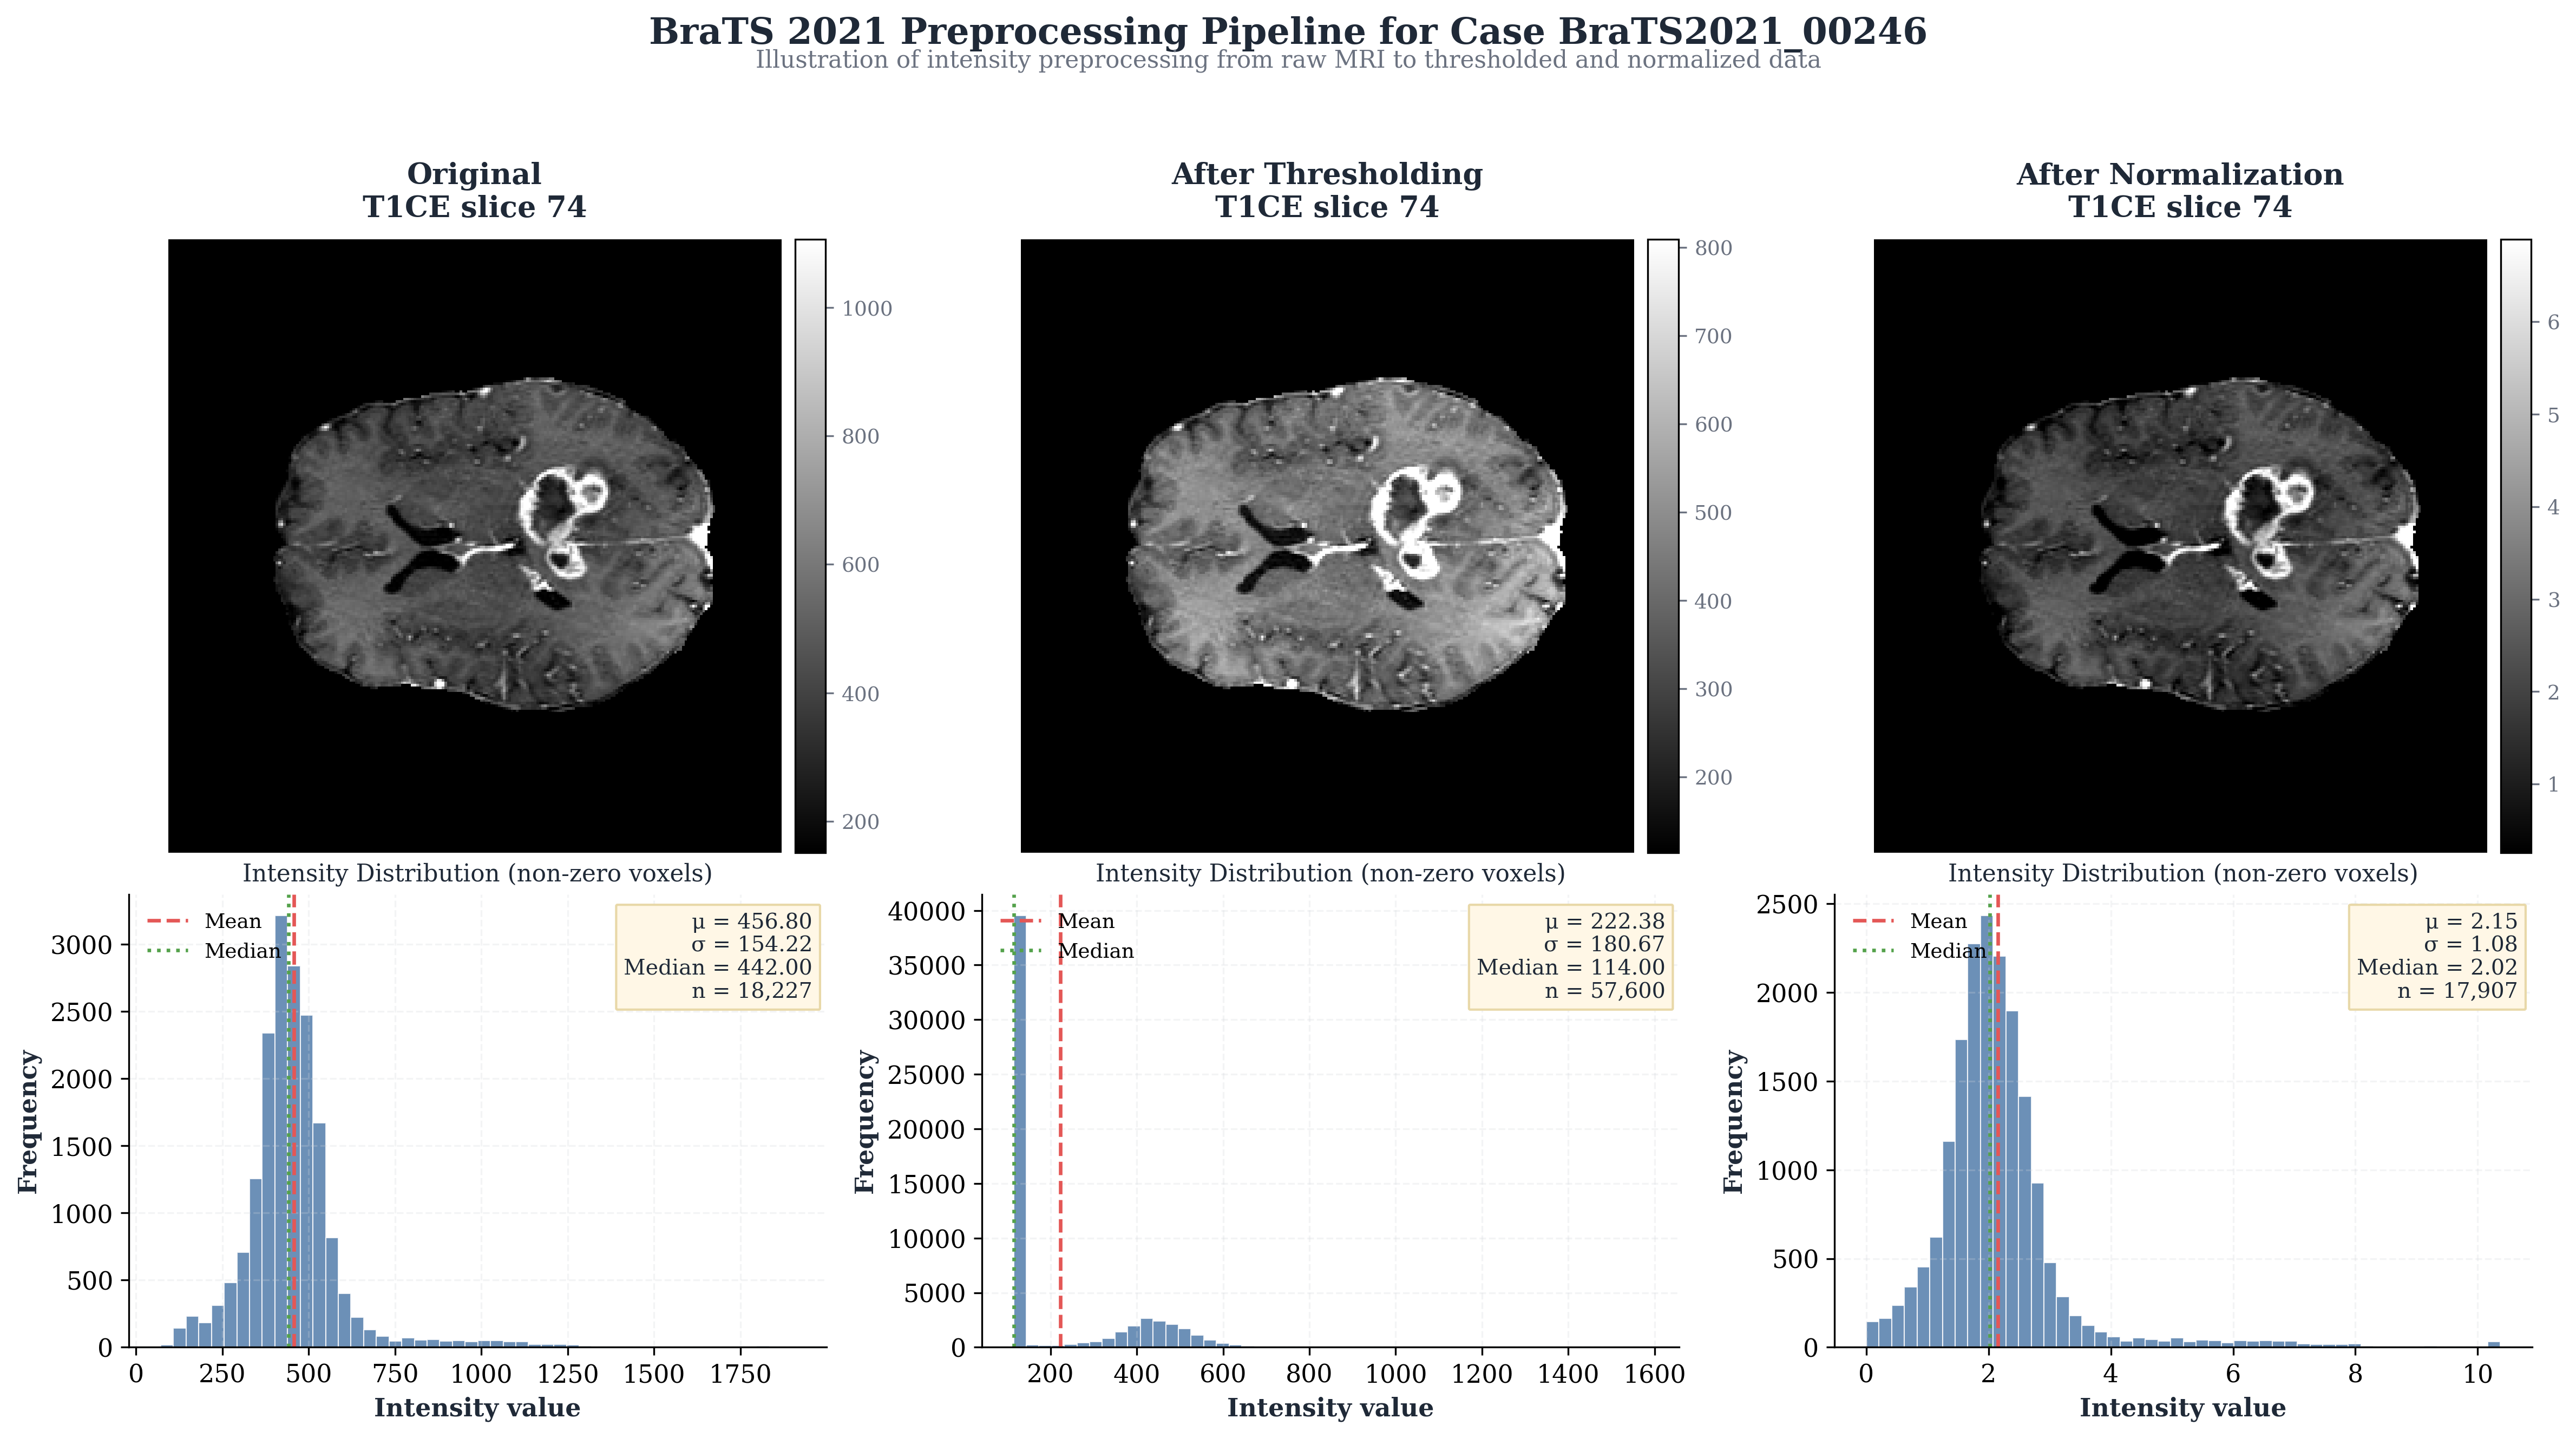

In [28]:
fig = visualize_preprocessing_stages(
    case_id=train_ids[0],
    dataset_root=TRAIN_DATASET_PATH,
    year=2021,
    modality="t1ce",
    save_path="preprocessing_stages_brats2021.png"
)
plt.show()

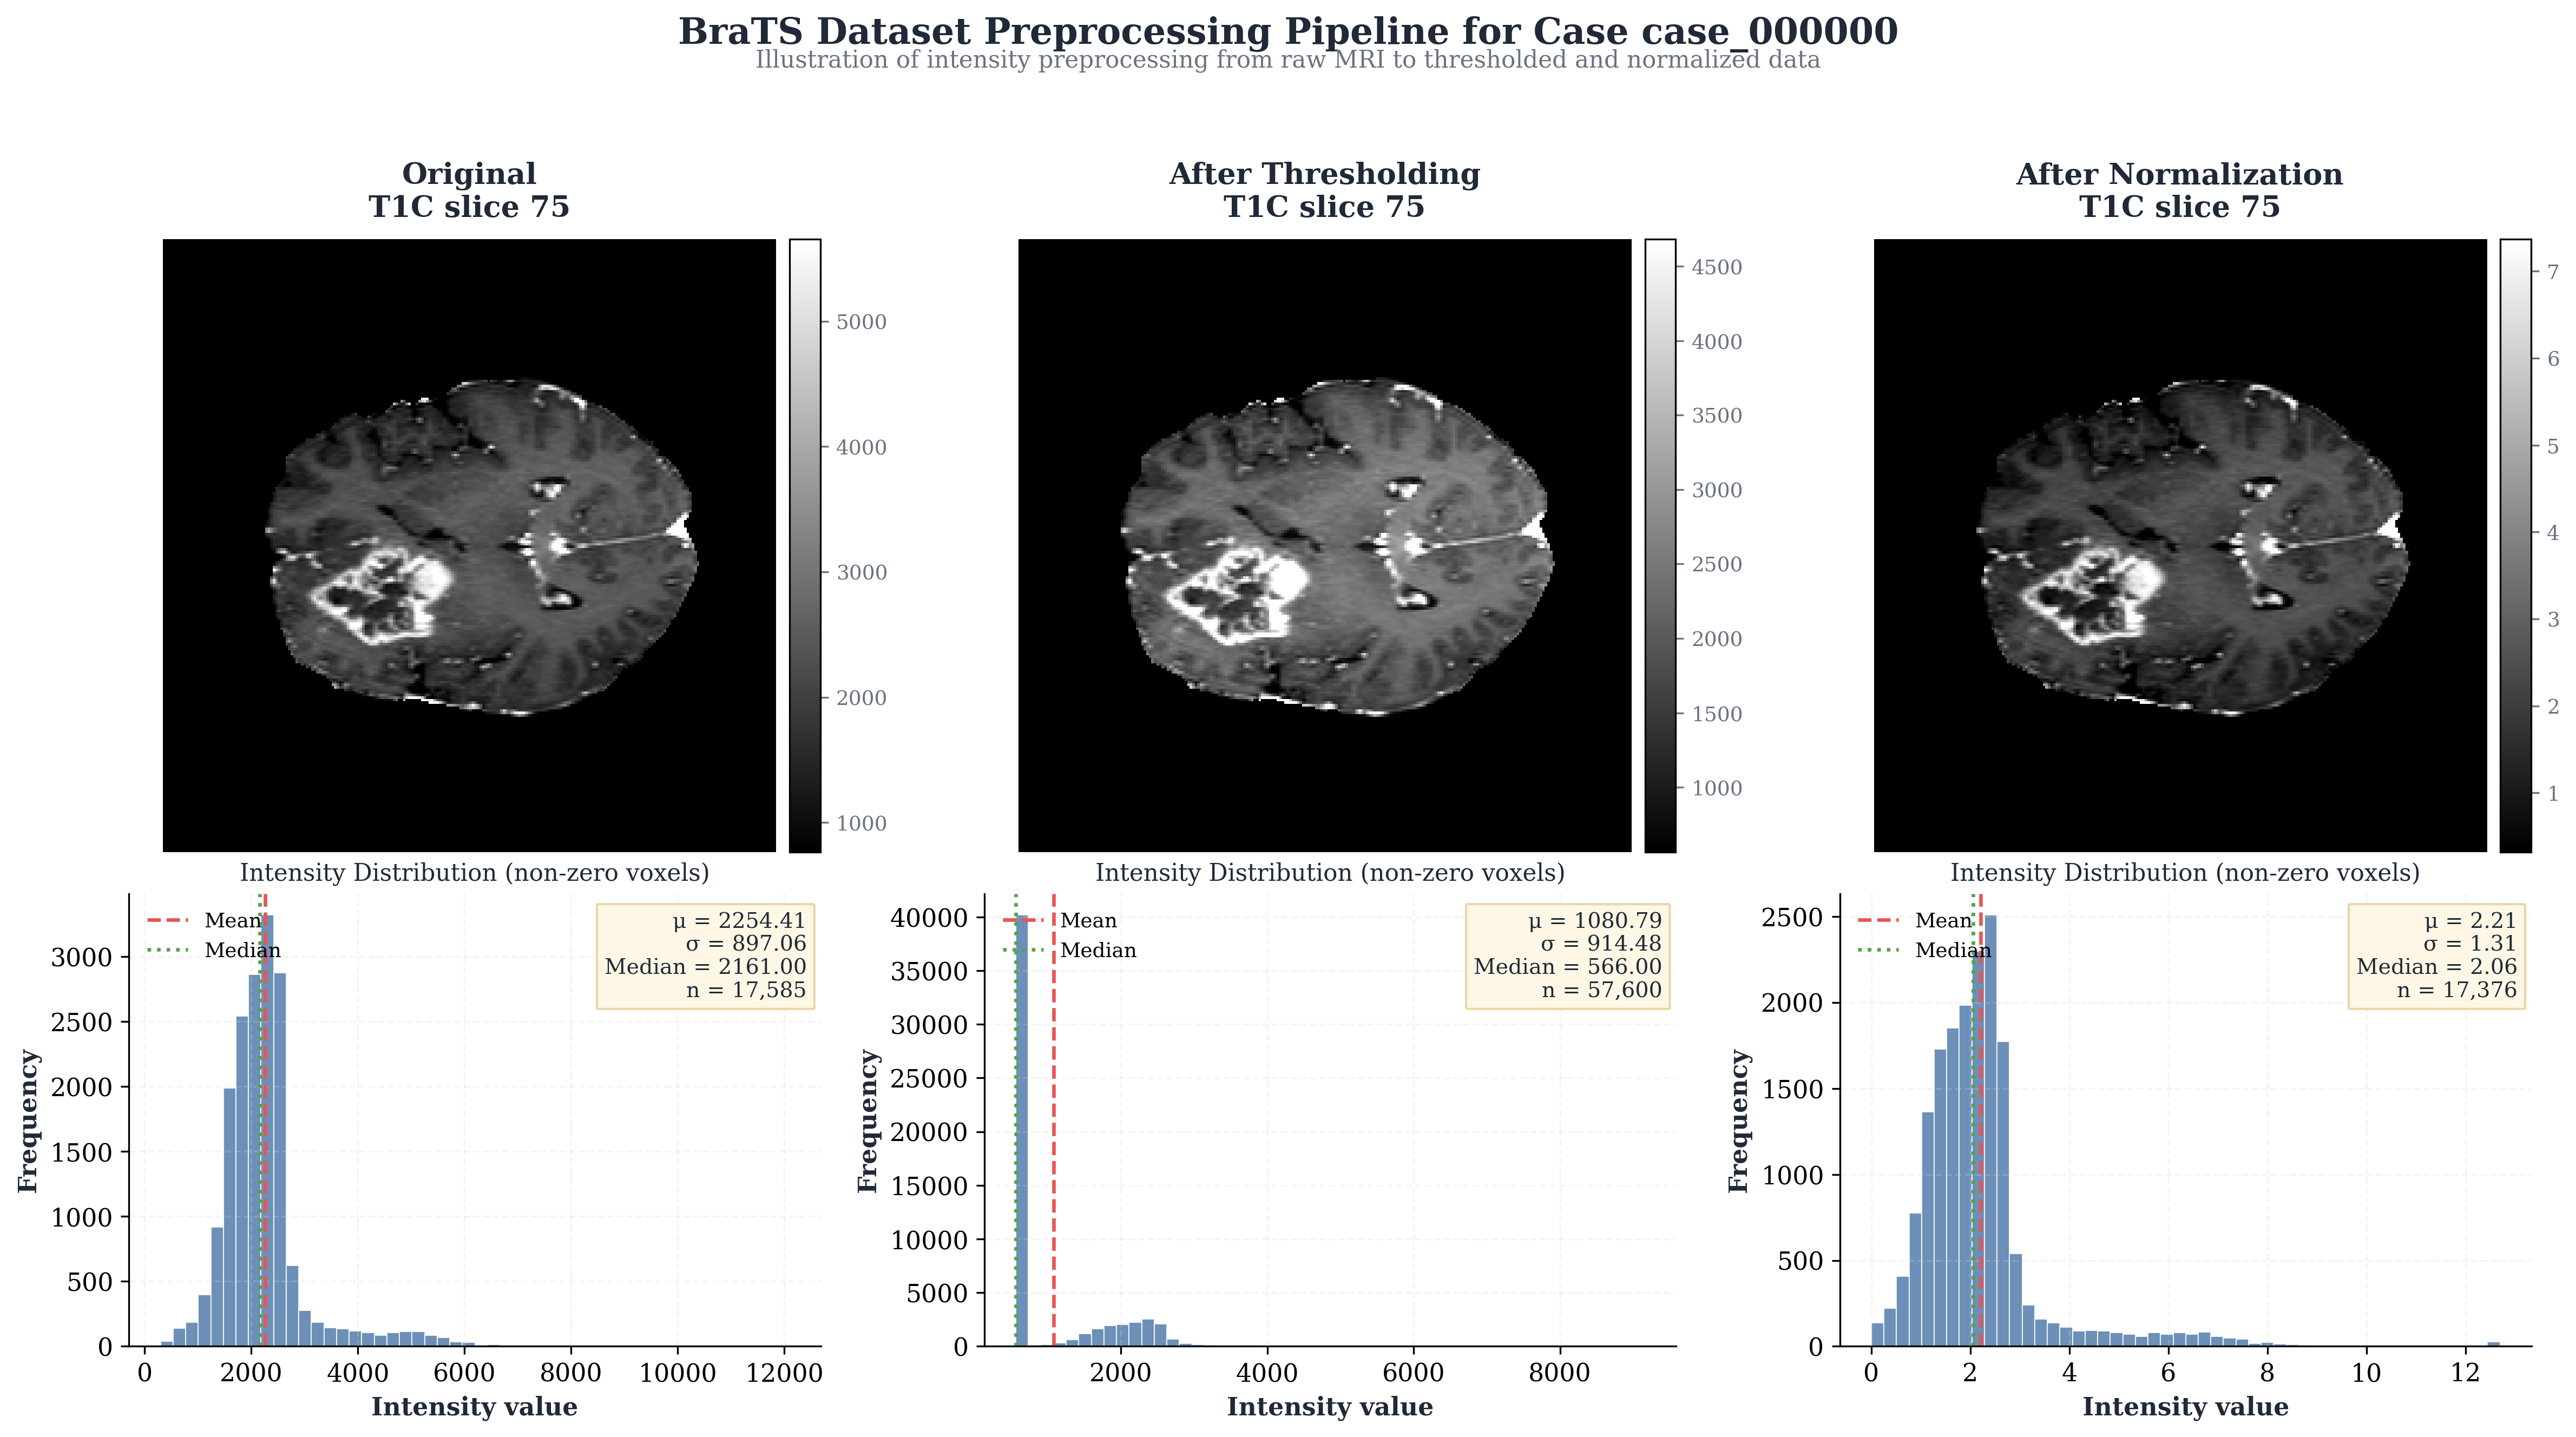

In [ ]:
fig = visualize_preprocessing_stages(
    case_id=evaluate_2_ids[0],
    dataset_root=EVALUATE_DATASET_2_PATH,
    year=None,
    modality="t1c",
    save_path="preprocessing_stages_brats_synthesis.png"
)
plt.show()

In [31]:
def analyze_and_visualize_dataset(
    training_generator,
    test_generator,
    training_loader,
    test_loader,
    num_samples=200,
    year=None,
    dataset_name="BraTS",
    class_names=None,
    class_colors=None,
    figsize=(13, 4.8),
    dpi=220,
    save_path=None
):
    print("Analyzing dataset distribution...")

    if class_names is None:
        class_names = ["Background", "Necrotic", "Edema", "Enhancing"]
    if class_colors is None:
        class_colors = ["#C9CED6", "#D95F5F", "#5AAE61", "#E6C84F"]

    num_classes = len(class_names)

    def to_numpy(x):
        if hasattr(x, "detach"):
            x = x.detach()
        if hasattr(x, "cpu"):
            x = x.cpu()
        if hasattr(x, "numpy"):
            return x.numpy()
        return np.asarray(x)

    def safe_pct(count, total):
        return (count / total * 100.0) if total > 0 else 0.0

    def get_num_patients(dataset):
        if hasattr(dataset, "list_IDs"):
            return len(dataset.list_IDs)
        if hasattr(dataset, "cases"):
            return len(dataset.cases)
        if hasattr(dataset, "case_ids"):
            return len(dataset.case_ids)
        return 0

    def extract_image_and_label(sample):
        image = None
        label = None

        if isinstance(sample, dict):
            for k in ["image", "images", "input", "x", "X"]:
                if k in sample:
                    image = sample[k]
                    break
            for k in ["mask", "seg", "label", "labels", "target", "y", "Y", "segmentation", "gt", "ground_truth"]:
                if k in sample:
                    label = sample[k]
                    break
            return image, label

        if isinstance(sample, (tuple, list)):
            if len(sample) >= 1:
                image = sample[0]
            if len(sample) >= 2:
                label = sample[1]
            return image, label

        return None, None

    def collect_stats(generator, n_samples, generator_name="generator"):
        class_counts = {i: 0 for i in range(num_classes)}
        tumor_ratios = []

        n_iter = min(n_samples, len(generator))
        label_available = None

        for i in range(n_iter):
            sample = generator[i]
            X, Y = extract_image_and_label(sample)

            if X is None:
                raise ValueError(f"Could not extract image from sample {i} in {generator_name}")

            if label_available is None:
                label_available = (Y is not None)

            if Y is not None:
                Y_np = to_numpy(Y)
                for cls in range(num_classes):
                    class_counts[cls] += int(np.sum(Y_np == cls))
                tumor_ratios.append(float(np.mean(Y_np > 0)) * 100.0)

        if label_available is None:
            label_available = False

        if label_available:
            total_voxels = sum(class_counts.values())
            class_pcts = [safe_pct(class_counts[i], total_voxels) for i in range(num_classes)]
            tumor_pct = float(np.sum(class_pcts[1:]))
        else:
            class_pcts = [np.nan] * num_classes
            tumor_pct = np.nan

        return {
            "label_available": label_available,
            "class_counts": class_counts,
            "class_pcts": class_pcts,
            "tumor_ratios": tumor_ratios,
            "tumor_pct": tumor_pct,
        }

    train_stats = collect_stats(training_generator, num_samples, "training_generator")
    test_stats = collect_stats(test_generator, num_samples, "test_generator")

    train_pcts = train_stats["class_pcts"]
    test_pcts = test_stats["class_pcts"]
    train_tumor_ratios = train_stats["tumor_ratios"]
    test_tumor_ratios = test_stats["tumor_ratios"]

    n_train_patients = get_num_patients(training_generator)
    n_test_patients = get_num_patients(test_generator)

    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")

    # ========= Panel A: horizontal stacked composition =========
    ax = axes[0]
    y_positions = [1, 0]   # Train on top, Test below
    labels = ["Train", "Test"]
    all_pcts = [train_pcts, test_pcts]

    for row_idx, (y, pcts) in enumerate(zip(y_positions, all_pcts)):
        left = 0
        for j, (cls, color, val) in enumerate(zip(class_names, class_colors, pcts)):
            ax.barh(
                y, val, left=left, height=0.42,
                color=color, edgecolor="white", linewidth=1.0
            )
            if val >= 7:
                ax.text(left + val / 2, y, f"{val:.1f}%", ha="center", va="center",
                        fontsize=10, fontweight="bold", color="#1F2937")
            left += val

    ax.set_xlim(0, 100)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontweight="bold")
    ax.set_xlabel("Voxel composition (%)", fontweight="bold")
    ax.set_title("Class Composition", fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # legend compact phía dưới
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=c, ec="white")
        for c in class_colors
    ]
    ax.legend(
        handles, class_names,
        ncol=4, frameon=False,
        bbox_to_anchor=(0.0, -0.18), loc="upper left",
        columnspacing=1.2, handletextpad=0.5
    )

    # ========= Panel B: ECDF tumor ratio =========
    ax = axes[1]

    def ecdf(vals):
        vals = np.sort(np.asarray(vals, dtype=float))
        y = np.arange(1, len(vals) + 1) / len(vals)
        return vals, y

    x1, y1 = ecdf(train_tumor_ratios)
    x2, y2 = ecdf(test_tumor_ratios)

    ax.plot(x1, y1, linewidth=2.4, label=f"Train (n={len(x1)})")
    ax.plot(x2, y2, linewidth=2.4, label=f"Test (n={len(x2)})")

    train_mean = float(np.mean(train_tumor_ratios))
    test_mean = float(np.mean(test_tumor_ratios))
    train_med = float(np.median(train_tumor_ratios))
    test_med = float(np.median(test_tumor_ratios))

    ax.axvline(train_med, linestyle="--", linewidth=1.3, alpha=0.8)
    ax.axvline(test_med, linestyle="--", linewidth=1.3, alpha=0.8)

    ax.text(train_med, 0.08, f"train median {train_med:.1f}%", fontsize=9, ha="left")
    ax.text(test_med, 0.18, f"test median {test_med:.1f}%", fontsize=9, ha="left")

    ax.set_xlabel("Tumor ratio per sample (%)", fontweight="bold")
    ax.set_ylabel("Cumulative proportion", fontweight="bold")
    ax.set_title("Tumor Ratio Distribution", fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="lower right")

    year_text = f" {year}" if year is not None else ""
    fig.suptitle(
        f"{dataset_name}{year_text}: dataset composition and tumor coverage",
        fontsize=16, fontweight="bold", y=1.02
    )

    # footnote nhỏ thay cho table/note box
    foot = (
        f"Train: {n_train_patients} items | "
        f"Test: {n_test_patients} items | "
        f"Mean tumor ratio: {train_mean:.1f}% vs {test_mean:.1f}%"
    )
    fig.text(0.5, -0.02, foot, ha="center", fontsize=10, color="#4B5563")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    stats = {
        "train_class_pcts": train_pcts,
        "test_class_pcts": test_pcts,
        "train_tumor_ratios": train_tumor_ratios,
        "test_tumor_ratios": test_tumor_ratios,
        "train_mean_tumor_ratio": train_mean,
        "test_mean_tumor_ratio": test_mean,
        "train_median_tumor_ratio": train_med,
        "test_median_tumor_ratio": test_med,
    }

    return fig, stats

Analyzing dataset distribution...


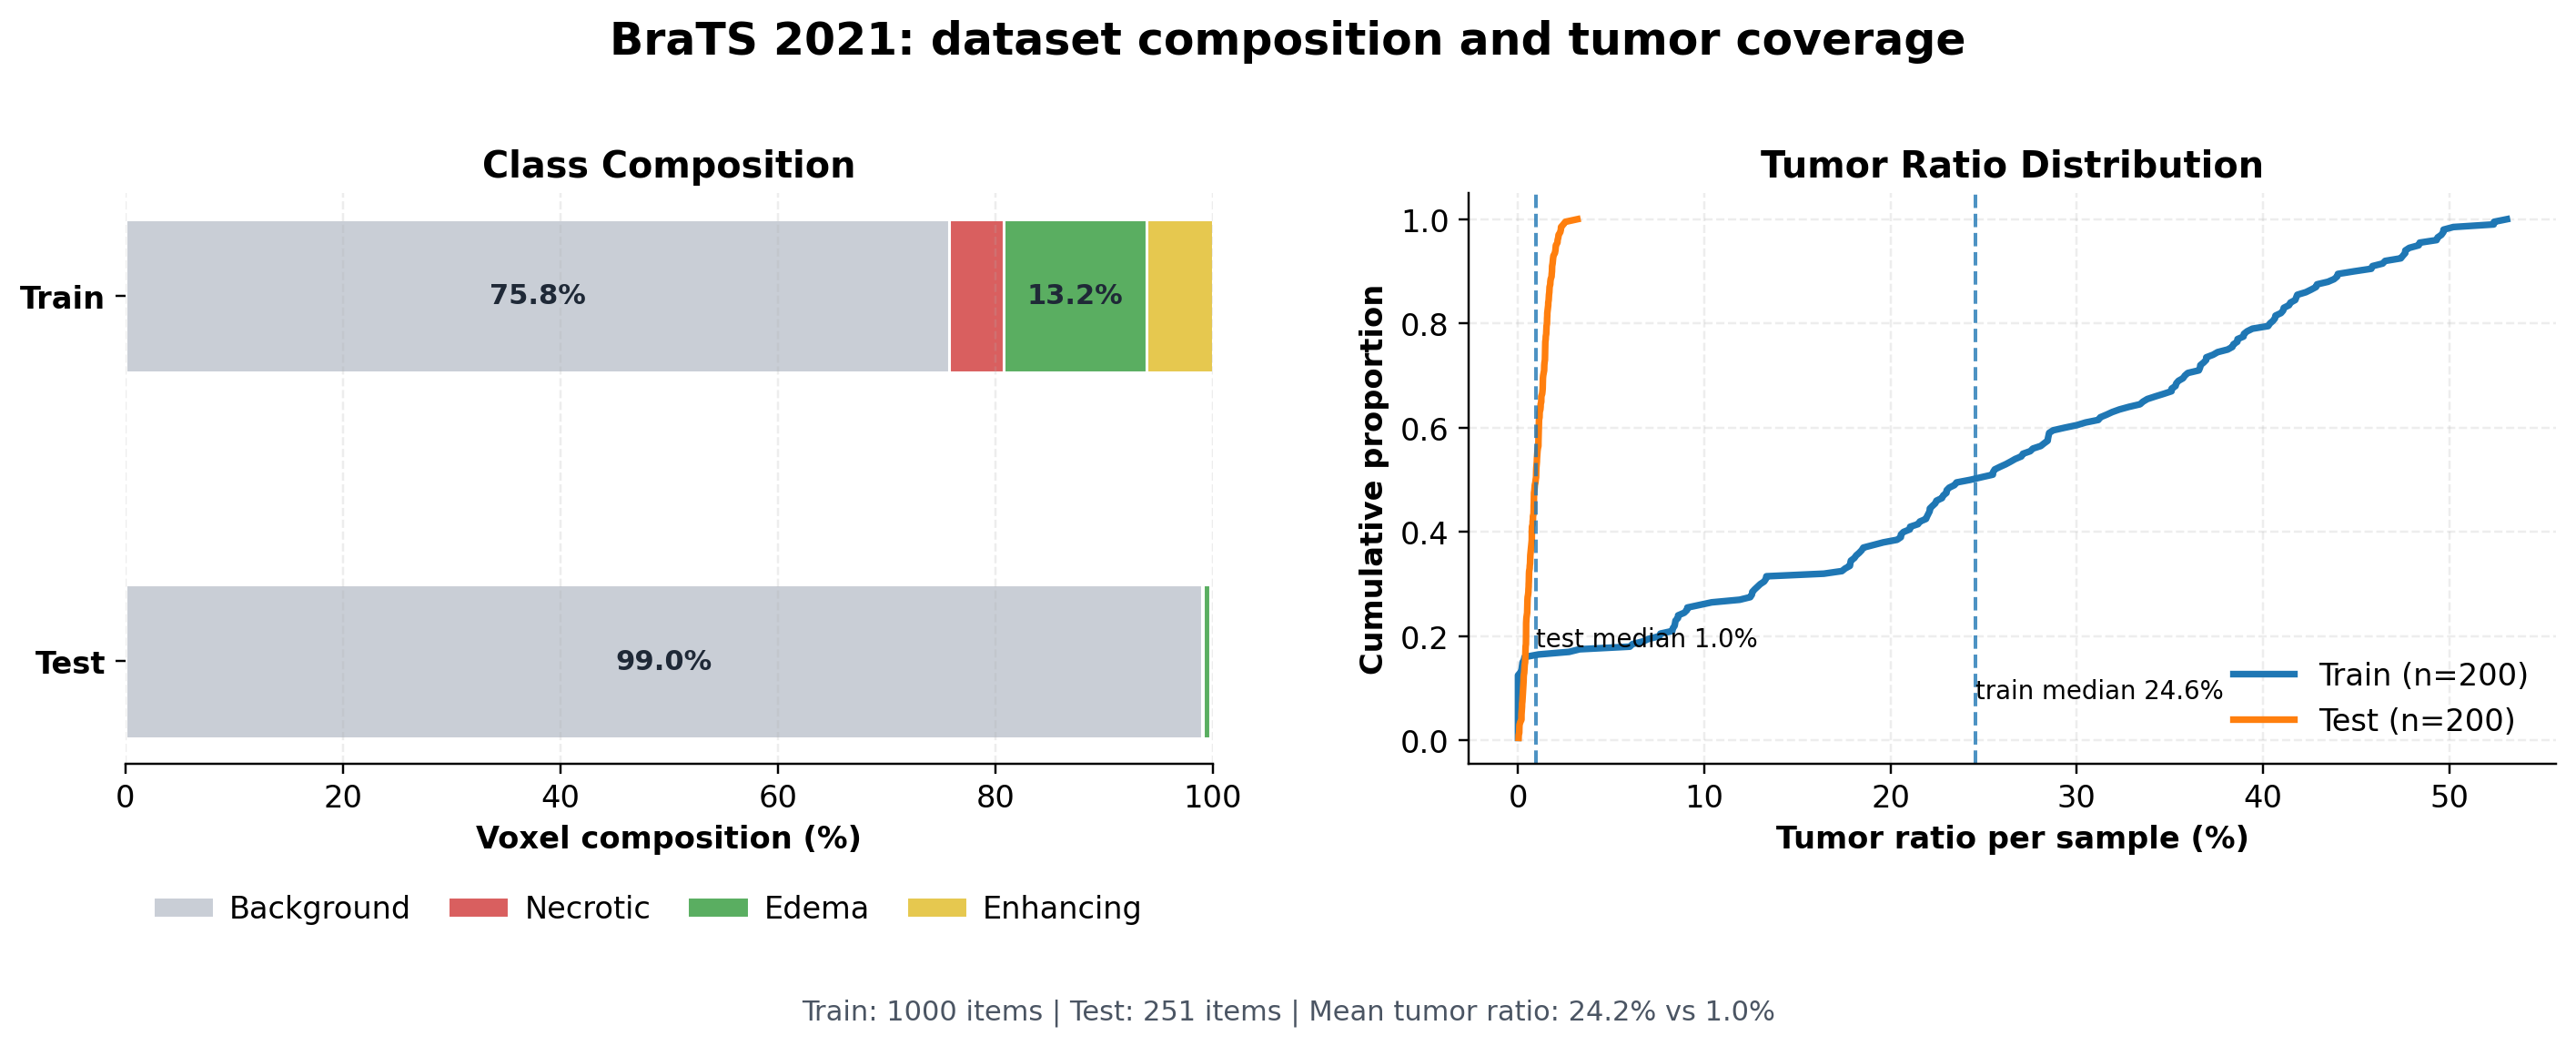

In [31]:
fig, stats = analyze_and_visualize_dataset(
    training_generator=training_generator,
    test_generator=test_dataset,
    training_loader=training_loader,
    test_loader=test_loader,
    num_samples=200,
    year=2021,
    dataset_name="BraTS",
    save_path="dataset_distribution_brats2021.png"
)
plt.show()

In [32]:
def analyze_and_visualize_dataset_extend(
    train_dataset,
    test_dataset,
    train_loader,
    test_loader,
    val_dataset=None,
    val_loader=None,
    num_samples=None,
    year=None,
    dataset_name="BraTS",
    class_names=None,
    class_colors=None,
    figsize=(14, 5.2),
    dpi=220,
    save_path=None,
):
    print("Analyzing dataset distribution with DataLoader...")

    if class_names is None:
        class_names = ["Background", "Necrotic", "Edema", "Enhancing"]
    if class_colors is None:
        class_colors = ["#C9CED6", "#D95F5F", "#5AAE61", "#E6C84F"]

    num_classes = len(class_names)

    def to_numpy(x):
        if x is None:
            return None
        if hasattr(x, "detach"):
            x = x.detach()
        if hasattr(x, "cpu"):
            x = x.cpu()
        if hasattr(x, "numpy"):
            return x.numpy()
        return np.asarray(x)

    def safe_pct(count, total):
        return (count / total * 100.0) if total > 0 else 0.0

    def get_num_patients(dataset):
        if dataset is None:
            return 0
        if hasattr(dataset, "list_IDs"):
            return len(dataset.list_IDs)
        if hasattr(dataset, "cases"):
            return len(dataset.cases)
        if hasattr(dataset, "case_ids"):
            return len(dataset.case_ids)
        return len(dataset)

    def extract_label_from_batch(batch):
        if isinstance(batch, dict):
            for k in ["mask", "seg", "label", "labels", "target", "y", "Y", "segmentation", "gt", "ground_truth"]:
                if k in batch:
                    return batch[k]
            return None

        if isinstance(batch, (tuple, list)):
            if len(batch) >= 2:
                return batch[1]
            return None

        return None

    def split_batch_to_samples(label_batch):
        arr = to_numpy(label_batch)
        if arr is None:
            return []

        # arr shape thường là:
        # [B, 1, H, W, D] hoặc [B, H, W, D]
        if arr.ndim == 5 and arr.shape[1] == 1:
            arr = arr[:, 0]   # -> [B, H, W, D]

        if arr.ndim == 4:
            return [arr[i] for i in range(arr.shape[0])]

        # fallback cho 1 sample không có batch dim
        return [arr]

    def collect_stats_from_loader(loader, dataset, split_name="split", max_samples=None):
        class_counts = np.zeros(num_classes, dtype=np.int64)
        tumor_ratios = []
        processed = 0
        label_available = None

        if loader is None:
            return {
                "label_available": False,
                "class_counts": {i: 0 for i in range(num_classes)},
                "class_pcts": [np.nan] * num_classes,
                "tumor_ratios": [],
                "tumor_pct": np.nan,
                "n_processed": 0,
            }

        for batch in loader:
            label_batch = extract_label_from_batch(batch)

            if label_available is None:
                label_available = (label_batch is not None)

            if label_batch is None:
                continue

            sample_labels = split_batch_to_samples(label_batch)

            for y_np in sample_labels:
                y_np = np.asarray(y_np, dtype=np.int64)

                counts = np.bincount(y_np.ravel(), minlength=num_classes)
                class_counts += counts[:num_classes]

                total_voxels = counts.sum()
                if total_voxels > 0:
                    tumor_ratio = 100.0 * (1.0 - counts[0] / total_voxels)
                else:
                    tumor_ratio = 0.0
                tumor_ratios.append(float(tumor_ratio))

                processed += 1
                if max_samples is not None and processed >= max_samples:
                    break

            if max_samples is not None and processed >= max_samples:
                break

        if label_available is None:
            label_available = False

        if label_available and class_counts.sum() > 0:
            total_voxels = int(class_counts.sum())
            class_pcts = [safe_pct(int(class_counts[i]), total_voxels) for i in range(num_classes)]
            tumor_pct = float(np.sum(class_pcts[1:]))
        else:
            class_pcts = [np.nan] * num_classes
            tumor_pct = np.nan

        return {
            "label_available": label_available,
            "class_counts": {i: int(class_counts[i]) for i in range(num_classes)},
            "class_pcts": class_pcts,
            "tumor_ratios": tumor_ratios,
            "tumor_pct": tumor_pct,
            "n_processed": processed,
        }

    has_val = val_dataset is not None and val_loader is not None

    train_stats = collect_stats_from_loader(
        train_loader, train_dataset, split_name="train", max_samples=num_samples
    )
    val_stats = (
        collect_stats_from_loader(
            val_loader, val_dataset, split_name="val", max_samples=num_samples
        )
        if has_val else None
    )
    test_stats = collect_stats_from_loader(
        test_loader, test_dataset, split_name="test", max_samples=num_samples
    )

    train_pcts = train_stats["class_pcts"]
    test_pcts = test_stats["class_pcts"]
    train_tumor_ratios = train_stats["tumor_ratios"]
    test_tumor_ratios = test_stats["tumor_ratios"]

    if has_val:
        val_pcts = val_stats["class_pcts"]
        val_tumor_ratios = val_stats["tumor_ratios"]

    n_train_patients = get_num_patients(train_dataset)
    n_test_patients = get_num_patients(test_dataset)
    n_val_patients = get_num_patients(val_dataset) if has_val else 0

    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")

    # ===== Panel A =====
    ax = axes[0]

    if has_val:
        y_positions = [2, 1, 0]
        labels = ["Train", "Val", "Test"]
        all_pcts = [train_pcts, val_pcts, test_pcts]
    else:
        y_positions = [1, 0]
        labels = ["Train", "Test"]
        all_pcts = [train_pcts, test_pcts]

    for y, pcts in zip(y_positions, all_pcts):
        left = 0
        for color, val in zip(class_colors, pcts):
            width = 0 if np.isnan(val) else val
            ax.barh(
                y, width, left=left, height=0.42,
                color=color, edgecolor="white", linewidth=1.0
            )
            if not np.isnan(val) and val >= 7:
                ax.text(
                    left + val / 2, y, f"{val:.1f}%",
                    ha="center", va="center",
                    fontsize=10, fontweight="bold", color="#1F2937"
                )
            left += width

    ax.set_xlim(0, 100)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontweight="bold")
    ax.set_xlabel("Voxel composition (%)", fontweight="bold")
    ax.set_title("Class Composition", fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec="white") for c in class_colors]
    ax.legend(
        handles, class_names,
        ncol=len(class_names), frameon=False,
        bbox_to_anchor=(0.0, -0.18), loc="upper left",
        columnspacing=1.2, handletextpad=0.5
    )

    # ===== Panel B =====
    ax = axes[1]

    def ecdf(vals):
        vals = np.sort(np.asarray(vals, dtype=float))
        if len(vals) == 0:
            return np.array([]), np.array([])
        y = np.arange(1, len(vals) + 1) / len(vals)
        return vals, y

    x1, y1 = ecdf(train_tumor_ratios)
    ax.plot(x1, y1, linewidth=2.4, label=f"Train (n={len(x1)})")

    train_mean = float(np.mean(train_tumor_ratios)) if len(train_tumor_ratios) else np.nan
    train_med = float(np.median(train_tumor_ratios)) if len(train_tumor_ratios) else np.nan

    if has_val:
        x2, y2 = ecdf(val_tumor_ratios)
        ax.plot(x2, y2, linewidth=2.4, label=f"Val (n={len(x2)})")
        val_mean = float(np.mean(val_tumor_ratios)) if len(val_tumor_ratios) else np.nan
        val_med = float(np.median(val_tumor_ratios)) if len(val_tumor_ratios) else np.nan
    else:
        val_mean = np.nan
        val_med = np.nan

    x3, y3 = ecdf(test_tumor_ratios)
    ax.plot(x3, y3, linewidth=2.4, label=f"Test (n={len(x3)})")
    test_mean = float(np.mean(test_tumor_ratios)) if len(test_tumor_ratios) else np.nan
    test_med = float(np.median(test_tumor_ratios)) if len(test_tumor_ratios) else np.nan

    if not np.isnan(train_med):
        ax.axvline(train_med, linestyle="--", linewidth=1.3, alpha=0.8)
        ax.text(train_med, 0.08, f"train median {train_med:.1f}%", fontsize=9, ha="left")

    if has_val and not np.isnan(val_med):
        ax.axvline(val_med, linestyle="--", linewidth=1.3, alpha=0.8)
        ax.text(val_med, 0.18, f"val median {val_med:.1f}%", fontsize=9, ha="left")

    if not np.isnan(test_med):
        y_text = 0.28 if has_val else 0.18
        ax.axvline(test_med, linestyle="--", linewidth=1.3, alpha=0.8)
        ax.text(test_med, y_text, f"test median {test_med:.1f}%", fontsize=9, ha="left")

    ax.set_xlabel("Tumor ratio per sample (%)", fontweight="bold")
    ax.set_ylabel("Cumulative proportion", fontweight="bold")
    ax.set_title("Tumor Ratio Distribution", fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="lower right")

    year_text = f" {year}" if year is not None else ""
    fig.suptitle(
        f"{dataset_name}{year_text}: dataset composition and tumor coverage",
        fontsize=16, fontweight="bold", y=1.02
    )

    if has_val:
        foot = (
            f"Train: {n_train_patients} items | "
            f"Val: {n_val_patients} items | "
            f"Test: {n_test_patients} items | "
            f"Mean tumor ratio: {train_mean:.1f}% / {val_mean:.1f}% / {test_mean:.1f}%"
        )
    else:
        foot = (
            f"Train: {n_train_patients} items | "
            f"Test: {n_test_patients} items | "
            f"Mean tumor ratio: {train_mean:.1f}% vs {test_mean:.1f}%"
        )

    fig.text(0.5, -0.02, foot, ha="center", fontsize=10, color="#4B5563")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    stats = {
        "train_class_pcts": train_pcts,
        "test_class_pcts": test_pcts,
        "train_tumor_ratios": train_tumor_ratios,
        "test_tumor_ratios": test_tumor_ratios,
        "train_mean_tumor_ratio": train_mean,
        "test_mean_tumor_ratio": test_mean,
        "train_median_tumor_ratio": train_med,
        "test_median_tumor_ratio": test_med,
        "train_processed": train_stats["n_processed"],
        "test_processed": test_stats["n_processed"],
    }

    if has_val:
        stats.update({
            "val_class_pcts": val_pcts,
            "val_tumor_ratios": val_tumor_ratios,
            "val_mean_tumor_ratio": val_mean,
            "val_median_tumor_ratio": val_med,
            "val_processed": val_stats["n_processed"],
        })

    return fig, stats

Analyzing dataset distribution with DataLoader...


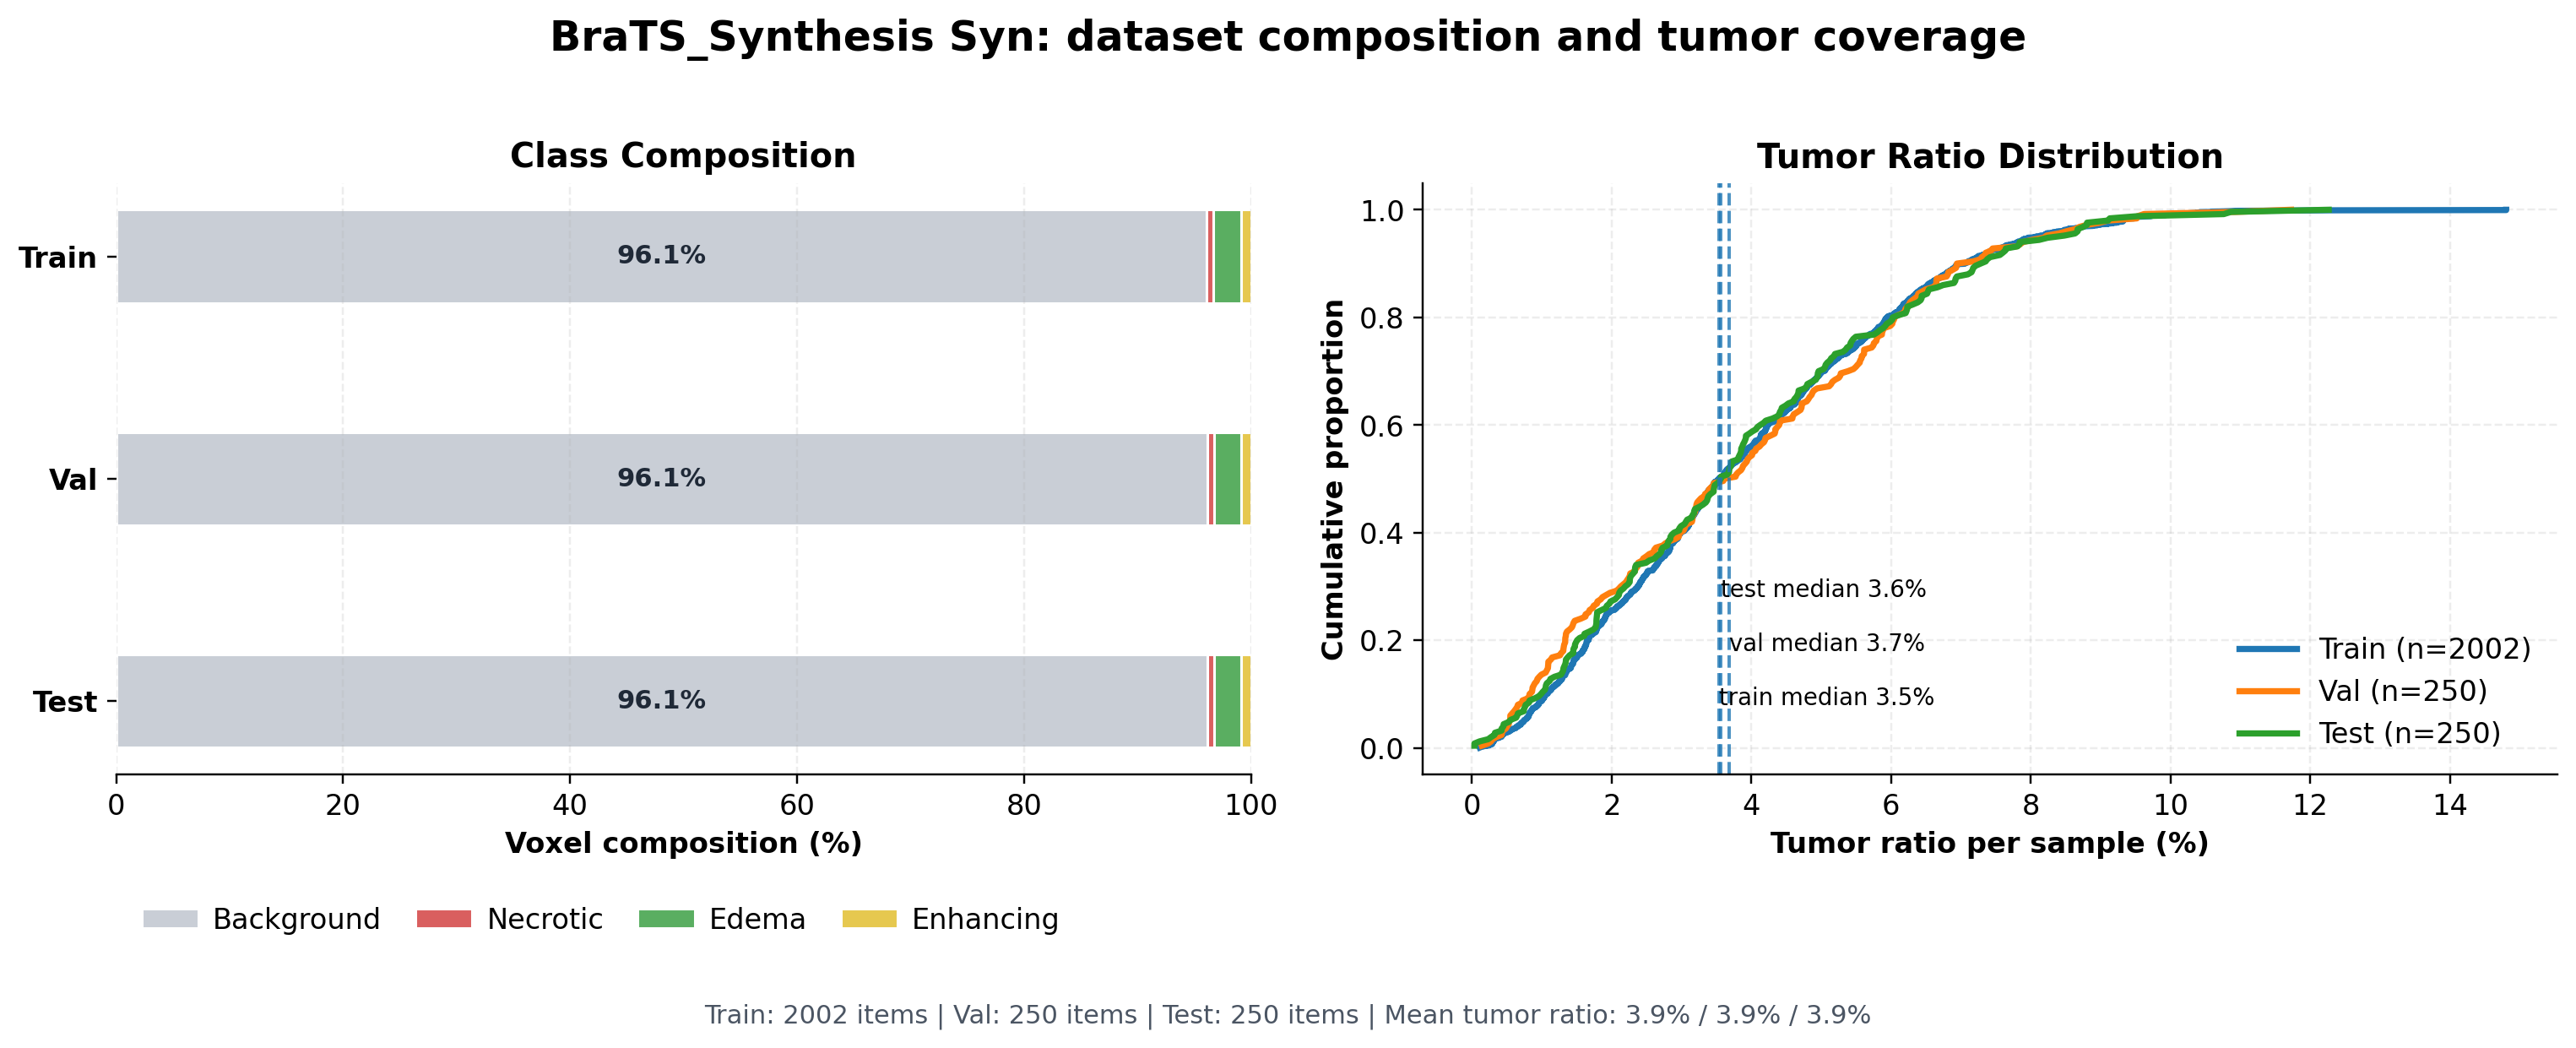

In [33]:
fig, stats = analyze_and_visualize_dataset_extend(
    train_dataset=train_syn_dataset,
    val_dataset=val_syn_dataset,
    test_dataset=test_syn_dataset,
    train_loader=train_syn_loader,
    val_loader=val_syn_loader,
    test_loader=test_syn_loader,
    num_samples=None,
    year="Syn",
    dataset_name="BraTS_Synthesis",
    save_path="dataset_distribution_brats_synthesis_v2.png"
)
plt.show()